In [2]:
#PBP and Tracking - Data is 100% accurate but players, teams and games are randomly generated of 8 NHL teams
import pandas as pd

pbp_df = pd.read_parquet("pbp.parquet")
tracking_df = pd.read_parquet("tracking.parquet")

print('pbp_df columns:', pbp_df.columns.tolist())
print('\ntracking_df columns:', tracking_df.columns.tolist())

team_cols = [c for c in pbp_df.columns if 'team_' in c and '_ids' in c]
opp_cols = [c for c in pbp_df.columns if 'opp_' in c and '_ids' in c]
print('\nteam id columns:', team_cols)
print('opp id columns:', opp_cols)

pbp_df columns: ['game_id', 'date', 'home_abbr', 'away_abbr', 'period', 'game_time', 'frame', 'score_differential', 'manpower_situation', 'team_n_skaters', 'team_f_ids', 'team_d_ids', 'team_g_id', 'opp_n_skaters', 'opp_f_ids', 'opp_d_ids', 'opp_g_id', 'player_id', 'player_position', 'event_team', 'team_in_possession', 'team_on_defense', 'is_possession_event', 'is_defensive_event', 'is_possession_breaking', 'is_last_play_of_possession', 'name', 'type', 'shorthand', 'outcome', 'flags', 'x_coord', 'y_coord', 'x_adj_coord', 'y_adj_coord', 'zone', 'play_section']

tracking_df columns: ['game_id', 'period', 'gt_ms', 'jersey', 'track_id', 'track_team', 'identity_confidence', 'motion_confidence', 'x', 'y', 'velocity_x', 'velocity_y', 'velocity_magnitude', 'acceleration_x', 'acceleration_y', 'acceleration_magnitude']

team id columns: ['team_f_ids', 'team_d_ids']
opp id columns: ['opp_f_ids', 'opp_d_ids']


In [3]:
import numpy as np

# Load lookup tables used to map IDs and home/away team context.
games_df = pd.read_csv("games.csv", usecols=["game_id", "home_team_id", "away_team_id"])
player_games_df = pd.read_csv(
    "player_games.csv",
    usecols=["game_id", "team_id", "player_id", "jersey_number"],
)

#Avoid merge issues 
pbp_work = pbp_df.copy()
tracking_work = tracking_df.copy()

for df in [pbp_work, tracking_work, games_df, player_games_df]:
    if "game_id" in df.columns:
        df["game_id"] = pd.to_numeric(df["game_id"], errors="coerce").astype("Int64")

if "period" in pbp_work.columns:
    pbp_work["period"] = pd.to_numeric(pbp_work["period"], errors="coerce").astype("Int64")
if "period" in tracking_work.columns:
    tracking_work["period"] = pd.to_numeric(tracking_work["period"], errors="coerce").astype("Int64")
if "track_team" in tracking_work.columns:
    tracking_work["track_team"] = pd.to_numeric(tracking_work["track_team"], errors="coerce").astype("Int64")

for col in ["team_id", "player_id", "jersey_number"]:
    if col in player_games_df.columns:
        player_games_df[col] = pd.to_numeric(player_games_df[col], errors="coerce").astype("Int64")
for col in ["home_team_id", "away_team_id"]:
    if col in games_df.columns:
        games_df[col] = pd.to_numeric(games_df[col], errors="coerce").astype("Int64")

#game_id and player_id -> jersey_number.
player_to_jersey = (
    player_games_df.dropna(subset=["game_id", "player_id", "jersey_number"])
    .drop_duplicates(["game_id", "player_id"])
    .set_index(["game_id", "player_id"])["jersey_number"]
    .to_dict()
 )

def _map_player_id_to_jersey(game_id, player_id):
    if pd.isna(player_id) or pd.isna(game_id):
        return pd.NA
    try:
        gid = int(game_id)
        pid = int(float(player_id))
    except (TypeError, ValueError):
        return pd.NA
    jersey = player_to_jersey.get((gid, pid))
    return pd.NA if pd.isna(jersey) else int(jersey)

def _map_id_list_to_jersey(game_id, value):
    if pd.isna(value) or pd.isna(game_id):
        return value
    ids = [x.strip() for x in str(value).split(",") if x.strip()]
    jerseys = []
    for pid_text in ids:
        jersey = _map_player_id_to_jersey(game_id, pid_text)
        jerseys.append("NA" if pd.isna(jersey) else str(jersey))
    return ", ".join(jerseys)

pbp_df_mapped = pbp_work.copy()

# Replace on-ice player ID columns with jersey numbers in pbp.
for col in ["team_f_ids", "team_d_ids", "opp_f_ids", "opp_d_ids"]:
    pbp_df_mapped[col] = pbp_df_mapped.apply(
        lambda r: _map_id_list_to_jersey(r["game_id"], r[col]), axis=1
    )

for col in ["team_g_id", "opp_g_id", "player_id"]:
    pbp_df_mapped[col] = pbp_df_mapped.apply(
        lambda r: _map_player_id_to_jersey(r["game_id"], r[col]), axis=1
    ).astype("Int64")

# Enrich tracking with true team_id from home/away context.
tracking_df_mapped = tracking_work.merge(games_df, on="game_id", how="left")
tracking_df_mapped["team_id"] = np.where(
    tracking_df_mapped["track_team"].eq(1),
    tracking_df_mapped["home_team_id"],
    tracking_df_mapped["away_team_id"],
)
tracking_df_mapped["team_id"] = pd.to_numeric(
    tracking_df_mapped["team_id"], errors="coerce"
).astype("Int64")

# Normalize tracking jersey and attach player_id where available.
tracking_df_mapped["jersey"] = pd.to_numeric(
    tracking_df_mapped["jersey"], errors="coerce"
).astype("Int64")

tracking_df_mapped = tracking_df_mapped.merge(
    player_games_df.rename(columns={"jersey_number": "jersey", "player_id": "resolved_player_id"}),
    on=["game_id", "team_id", "jersey"],
    how="left",
)

#Per-period track_id to jersey mapping
def _mode_or_first(values: pd.Series):
    values = values.dropna()
    if values.empty:
        return pd.NA
    mode_vals = values.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else values.iloc[0]

track_to_jersey = (
    tracking_df_mapped.groupby(["game_id", "period", "track_team", "track_id"])["jersey"]
    .agg(_mode_or_first)
    .rename("track_jersey")
    .reset_index()
)

tracking_df_mapped = tracking_df_mapped.merge(
    track_to_jersey,
    on=["game_id", "period", "track_team", "track_id"],
    how="left",
)
tracking_df_mapped["track_jersey"] = tracking_df_mapped["track_jersey"].astype("Int64")

# Apply mapping results back into the original working dataframes.
pbp_df = pbp_df_mapped.copy()
tracking_df = tracking_df_mapped.copy()

# Replace track_id with jersey-level identifier, but keep the original for traceability.
if "track_id_raw" not in tracking_df.columns:
    tracking_df["track_id_raw"] = tracking_df["track_id"]
tracking_df["track_id"] = tracking_df["track_jersey"].astype("Int64")

# Standardize player_id column on tracking to the resolved player mapping.
tracking_df["player_id"] = pd.to_numeric(
    tracking_df.get("resolved_player_id"), errors="coerce"
).astype("Int64")

print("Updated base dataframes in-place:")
print("- pbp_df now uses jersey numbers in on-ice/player columns")
print("- tracking_df now has track_id replaced by jersey (original kept in track_id_raw)")
print("- tracking_df.player_id set from resolved_player_id")

print("\nPBP sample:")
display(pbp_df[["game_id", "team_f_ids", "team_d_ids", "team_g_id", "opp_f_ids", "opp_d_ids", "opp_g_id", "player_id"]].head(5))

print("\nTracking sample:")
display(tracking_df[["game_id", "period", "track_team", "team_id", "track_id", "track_id_raw", "jersey", "player_id"]].head(5))

Updated base dataframes in-place:
- pbp_df now uses jersey numbers in on-ice/player columns
- tracking_df now has track_id replaced by jersey (original kept in track_id_raw)
- tracking_df.player_id set from resolved_player_id

PBP sample:


,game_id,team_f_ids,team_d_ids,team_g_id,opp_f_ids,opp_d_ids,opp_g_id,player_id
0,186402,"49, 20, 93","51, 17",33,"28, 71, 37","5, 19",52,<NA>
1,186402,"49, 20, 93","51, 17",33,"28, 71, 37","5, 19",52,49
2,186402,"28, 71, 37","5, 19",52,"49, 20, 93","51, 17",33,28
3,186402,"49, 20, 93","51, 17",33,"28, 71, 37","5, 19",52,49
4,186402,"28, 71, 37","5, 19",52,"49, 20, 93","51, 17",33,28



Tracking sample:


,game_id,period,track_team,team_id,track_id,track_id_raw,jersey,player_id
0,171065,1,2,1384,7,4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328c...,7,47829
1,171065,1,2,1384,84,ef2d127de37b942baad06145e54b0c619a1f22327b2ebb...,84,43733
2,171065,1,1,1382,22,e7f6c011776e8db7cd330b54174fd76f7d0216b612387a...,22,43282
3,171065,1,2,1384,32,7902699be42c8a8e46fbbb4501726517e86b22c56a189f...,32,39574
4,171065,1,1,1382,58,2c624232cdd221771294dfbb310aca000a0df6ac8b66b6...,58,52869


In [4]:
# Convert tracking gt_ms from milliseconds to seconds for direct alignment with pbp
def _convert_gt_ms_to_seconds(df: pd.DataFrame, frame_name: str):
    if "gt_ms" not in df.columns:
        print(f"{frame_name}: no gt_ms column found")
        return

    gt_numeric = pd.to_numeric(df["gt_ms"], errors="coerce")

    # Keep the original millisecond values for traceability.
    if "gt_ms_raw" not in df.columns:
        df["gt_ms_raw"] = gt_numeric

    # Only divide when values appear to be in milliseconds.
    max_val = gt_numeric.max(skipna=True)
    if pd.notna(max_val) and max_val > 5000:
        df["gt_ms"] = (gt_numeric / 1000.0).astype("Float64")
        print(f"{frame_name}: converted gt_ms from milliseconds to seconds")
    else:
        df["gt_ms"] = gt_numeric.astype("Float64")
        print(f"{frame_name}: gt_ms already appears to be in seconds; left as-is")

    # Optional explicit alias for readability in downstream code.
    df["gt_sec"] = df["gt_ms"]

_convert_gt_ms_to_seconds(tracking_df, "tracking_df")

if "tracking_df_mapped" in globals() and isinstance(tracking_df_mapped, pd.DataFrame):
    _convert_gt_ms_to_seconds(tracking_df_mapped, "tracking_df_mapped")

print("tracking_df gt_ms range:", float(pd.to_numeric(tracking_df["gt_ms"], errors="coerce").min()), "to", float(pd.to_numeric(tracking_df["gt_ms"], errors="coerce").max()))
print("pbp_df game_time range:", float(pd.to_numeric(pbp_df["game_time"], errors="coerce").min()), "to", float(pd.to_numeric(pbp_df["game_time"], errors="coerce").max()))

tracking_df: converted gt_ms from milliseconds to seconds
tracking_df_mapped: converted gt_ms from milliseconds to seconds
tracking_df gt_ms range: 0.0 to 4397.4
pbp_df game_time range: 0.0 to 4199.9666666667


In [5]:
#Verification that jersey mapping is accurate  
required = {
    "player_games_df": ["game_id", "team_id", "player_id", "jersey_number"],
    "tracking_df": ["game_id", "team_id", "player_id", "jersey", "track_id"],
}

missing_objects = []
missing_columns = []
for name, cols in required.items():
    if name not in globals():
        missing_objects.append(name)
        continue
    obj = globals()[name]
    if not hasattr(obj, "columns"):
        missing_objects.append(name)
        continue
    for col in cols:
        if col not in obj.columns:
            missing_columns.append(f"{name}.{col}")

if missing_objects or missing_columns:
    problems = []
    if missing_objects:
        problems.append("Missing objects: " + ", ".join(missing_objects))
    if missing_columns:
        problems.append("Missing columns: " + ", ".join(missing_columns))
    raise AssertionError("Verification failed. " + " | ".join(problems))

# Build expected jersey by (game_id, team_id, player_id).
lookup = player_games_df[["game_id", "team_id", "player_id", "jersey_number"]].copy()
for c in ["game_id", "team_id", "player_id", "jersey_number"]:
    lookup[c] = pd.to_numeric(lookup[c], errors="coerce").astype("Int64")
lookup = lookup.dropna(subset=["game_id", "team_id", "player_id", "jersey_number"])
lookup = lookup.drop_duplicates(["game_id", "team_id", "player_id"])
lookup = lookup.rename(columns={"jersey_number": "expected_jersey"})

trk = tracking_df[["game_id", "team_id", "player_id", "jersey", "track_id"]].copy()
for c in ["game_id", "team_id", "player_id", "jersey", "track_id"]:
    trk[c] = pd.to_numeric(trk[c], errors="coerce").astype("Int64")

merged = trk.merge(lookup, on=["game_id", "team_id", "player_id"], how="left")

# 1) track_id should match jersey after replacement (where both are known).
track_vs_jersey = merged[merged["track_id"].notna() & merged["jersey"].notna()]
track_jersey_mismatch = int((track_vs_jersey["track_id"] != track_vs_jersey["jersey"]).sum())

# 2) jersey in tracking should match expected jersey from lookup.
jersey_comparable = merged[merged["jersey"].notna() & merged["expected_jersey"].notna()]
jersey_mismatch = int((jersey_comparable["jersey"] != jersey_comparable["expected_jersey"]).sum())

# 3) track_id should also match expected jersey.
track_comparable = merged[merged["track_id"].notna() & merged["expected_jersey"].notna()]
track_mismatch = int((track_comparable["track_id"] != track_comparable["expected_jersey"]).sum())

print(f"tracking_df rows: {len(trk):,}")
print(f"Rows with lookup match (game/team/player): {merged['expected_jersey'].notna().sum():,}")
print(f"track_id vs jersey mismatches: {track_jersey_mismatch:,} / {len(track_vs_jersey):,}")
print(f"jersey vs expected mismatches: {jersey_mismatch:,} / {len(jersey_comparable):,}")
print(f"track_id vs expected mismatches: {track_mismatch:,} / {len(track_comparable):,}")

if track_jersey_mismatch or jersey_mismatch or track_mismatch:
    bad = merged.loc[
        (merged["track_id"].notna() & merged["jersey"].notna() & (merged["track_id"] != merged["jersey"]))
        | (merged["jersey"].notna() & merged["expected_jersey"].notna() & (merged["jersey"] != merged["expected_jersey"]))
        | (merged["track_id"].notna() & merged["expected_jersey"].notna() & (merged["track_id"] != merged["expected_jersey"])),
        ["game_id", "team_id", "player_id", "track_id", "jersey", "expected_jersey"],
    ].head(10)
    print("\nSample mismatches:")
    display(bad)
    raise AssertionError("Jersey verification failed. See mismatch counts above.")

print("Jersey verification passed.")

tracking_df rows: 12,458,760
Rows with lookup match (game/team/player): 12,288,137
track_id vs jersey mismatches: 0 / 12,288,137
jersey vs expected mismatches: 0 / 12,288,137
track_id vs expected mismatches: 0 / 12,288,137
Jersey verification passed.


In [6]:
# Puck Management Rating (100 = average, 110 = 10% better than average).
import numpy as np

player_lookup = pd.read_csv(
    "player_games.csv",
    usecols=["game_id", "team_id", "player_id", "first_name", "last_name", "jersey_number", "position"],
)
for c in ["game_id", "team_id", "player_id", "jersey_number"]:
    player_lookup[c] = pd.to_numeric(player_lookup[c], errors="coerce").astype("Int64")

# Forwards, defense, and goalies have structurally different puck-touch profiles (where on
# the ice they touch it, how often, what a "good" outcome looks like), so every rating below
# is built and normalized within these three groups rather than pooled across all positions.
def _position_group(pos) -> str:
    p = str(pos).strip().upper()
    if p in {"F", "C", "LW", "RW"}:
        return "F"
    if p in {"D", "LD", "RD"}:
        return "D"
    if p == "G":
        return "G"
    return "UNK"

player_lookup["position_group"] = player_lookup["position"].apply(_position_group)

game_meta = pd.read_csv(
    "games.csv",
    usecols=[
        "game_id",
        "home_team_id",
        "away_team_id",
        "home_team_short",
        "away_team_short",
        "home_team_loc",
        "away_team_loc",
        "home_team_name",
        "away_team_name",
    ],
)
for c in ["game_id", "home_team_id", "away_team_id"]:
    game_meta[c] = pd.to_numeric(game_meta[c], errors="coerce").astype("Int64")

pm = pbp_df.copy()
pm["game_id"] = pd.to_numeric(pm["game_id"], errors="coerce").astype("Int64")
pm = pm.merge(game_meta, on="game_id", how="left")

pm["event_team_text"] = pm["event_team"].astype(str).str.strip().str.upper()
pm["home_abbr"] = pm["home_abbr"].astype(str).str.strip().str.upper()
pm["away_abbr"] = pm["away_abbr"].astype(str).str.strip().str.upper()

def _contains_token(text, token) -> bool:
    text = str(text).upper()
    token = str(token).upper()
    return token not in {"", "NAN", "<NA>"} and token in text

def _resolve_event_team_id(row):
    text = str(row.get("event_team_text", "")).upper()
    home_tokens = [row.get("home_abbr", ""), row.get("home_team_short", ""), row.get("home_team_loc", ""), row.get("home_team_name", "")]
    away_tokens = [row.get("away_abbr", ""), row.get("away_team_short", ""), row.get("away_team_loc", ""), row.get("away_team_name", "")]

    home_match = any(_contains_token(text, t) for t in home_tokens)
    away_match = any(_contains_token(text, t) for t in away_tokens)
    if home_match and not away_match:
        return row["home_team_id"]
    if away_match and not home_match:
        return row["away_team_id"]

    code = text.split(" ")[0] if text else ""
    if code == str(row.get("home_abbr", "")).upper():
        return row["home_team_id"]
    if code == str(row.get("away_abbr", "")).upper():
        return row["away_team_id"]
    return pd.NA

pm["event_team_id"] = pm.apply(_resolve_event_team_id, axis=1)
pm["event_team_id"] = pd.to_numeric(pm["event_team_id"], errors="coerce").astype("Int64")
pm["player_jersey"] = pd.to_numeric(pm["player_id"], errors="coerce").astype("Int64")
pm["game_time"] = pd.to_numeric(pm["game_time"], errors="coerce").astype(float)

pm["is_poss_event"] = pm["is_possession_event"].fillna(False).astype(bool)
pm = pm[pm["is_poss_event"] & pm["player_jersey"].notna() & pm["event_team_id"].notna()].copy()

for c in ["zone", "play_section", "name", "type", "shorthand", "outcome", "player_position"]:
    pm[c] = pm[c].astype(str).str.lower().str.strip()

def _zone_weight(position: str, zone: str) -> float:
    if position in {"c", "lw", "rw", "f"}:
        return {"oz": 0.40, "nz": 0.35, "dz": 0.25}.get(zone, 0.33)
    if position in {"d", "ld", "rd"}:
        return {"dz": 0.40, "nz": 0.35, "oz": 0.25}.get(zone, 0.33)
    if position == "g":
        # Goalie touches are overwhelmingly behind/beside their own net; a rare delayed-penalty
        # OZ touch shouldn't carry the same weight as a routine DZ puck play.
        return {"dz": 0.55, "nz": 0.30, "oz": 0.15}.get(zone, 0.40)
    return 0.33

pm["zone_weight"] = [_zone_weight(pos, z) for pos, z in zip(pm["player_position"], pm["zone"])]
pm["pass_zone_bonus"] = np.where(pm["zone"].eq("nz"), 1.20, 1.00)

section_text = pm["play_section"].fillna("")
pm["turnover_loc_weight"] = np.select(
    [
        section_text.str.contains(r"board|wall", regex=True),
        section_text.str.contains(r"middle|center|slot", regex=True),
    ],
    [0.70, 1.20],
    default=1.00,
)

signal_text = (pm["name"].fillna("") + " " + pm["type"].fillna("") + " " + pm["shorthand"].fillna("")).str.lower()
outcome_text = pm["outcome"].fillna("").str.lower()

pm["is_pass_attempt"] = signal_text.str.contains(r"pass", regex=True, na=False)
pm["is_pass_success"] = pm["is_pass_attempt"] & outcome_text.str.contains(r"success|complete", regex=True, na=False)
pm["is_pass_fail"] = pm["is_pass_attempt"] & outcome_text.str.contains(r"fail|incomplete|broken", regex=True, na=False)
pm["is_turnover"] = (
    pm["is_possession_breaking"].fillna(False).astype(bool)
    | pm["is_pass_fail"]
    | outcome_text.str.contains(r"turnover|lost", regex=True, na=False)
)

pm["is_lpr"] = signal_text.str.contains(r"\blpr\b|loose\s*puck\s*recover", regex=True, na=False)
pm["is_dumpin"] = signal_text.str.contains(r"dump\s*-?\s*in", regex=True, na=False)
pm["is_dumpin_against"] = signal_text.str.contains(r"dump\s*-?\s*in\s*-?\s*against|dumpinagainst", regex=True, na=False)
pm.loc[pm["is_dumpin_against"], "is_dumpin"] = False

pm = pm.sort_values(["game_id", "period", "game_time"]).reset_index(drop=True)
pm["dump_success"] = False

for (gid, per), g in pm.groupby(["game_id", "period"], sort=False):
    idx = g.index.to_numpy()
    t = g["game_time"].to_numpy(dtype=float)
    team = g["event_team_id"].to_numpy(dtype=float)
    zone = g["zone"].astype(str).to_numpy()
    is_dump = g["is_dumpin"].to_numpy(dtype=bool)
    is_dump_against = g["is_dumpin_against"].to_numpy(dtype=bool)
    is_pass = g["is_pass_attempt"].to_numpy(dtype=bool)
    is_lpr = g["is_lpr"].to_numpy(dtype=bool)

    n = len(g)
    for i in range(n):
        if not (is_dump[i] or is_dump_against[i]):
            continue
        t0 = t[i]
        success = False
        j = i + 1
        while j < n and (t[j] - t0) <= 10.0:
            same_team = team[j] == team[i]
            if same_team:
                if is_dump[i] and (is_pass[j] or is_lpr[j]):
                    success = True
                    break
                if is_dump_against[i] and zone[j] == "nz":
                    success = True
                    break
            j += 1
        if success:
            pm.at[idx[i], "dump_success"] = True

pm["touch_w"] = pm["zone_weight"]
pm["pass_att_w"] = np.where(pm["is_pass_attempt"], pm["zone_weight"] * pm["pass_zone_bonus"], 0.0)
pm["pass_succ_w"] = np.where(pm["is_pass_success"], pm["zone_weight"] * pm["pass_zone_bonus"], 0.0)
pm["turnover_w"] = np.where(pm["is_turnover"], pm["zone_weight"] * pm["turnover_loc_weight"], 0.0)
pm["lpr_w"] = np.where(pm["is_lpr"], pm["zone_weight"], 0.0)
pm["dump_att_w"] = np.where(pm["is_dumpin"] | pm["is_dumpin_against"], pm["zone_weight"], 0.0)
pm["dump_succ_w"] = np.where(pm["dump_success"], pm["zone_weight"], 0.0)

player_scores = (
    pm.groupby(["event_team_id", "player_jersey"], as_index=False)
    .agg(
        touches=("is_poss_event", "size"),
        touch_w=("touch_w", "sum"),
        pass_att_w=("pass_att_w", "sum"),
        pass_succ_w=("pass_succ_w", "sum"),
        turnover_w=("turnover_w", "sum"),
        lpr_w=("lpr_w", "sum"),
        dump_att_w=("dump_att_w", "sum"),
        dump_succ_w=("dump_succ_w", "sum"),
    )
)

player_scores["pass_eff"] = (player_scores["pass_succ_w"] / player_scores["pass_att_w"].replace(0, np.nan)).clip(0, 1)
player_scores["turnover_rate"] = (player_scores["turnover_w"] / player_scores["touch_w"].replace(0, np.nan)).clip(0, 1)
player_scores["lpr_rate"] = (player_scores["lpr_w"] / player_scores["touch_w"].replace(0, np.nan)).clip(0, 1)
player_scores["dump_success_rate"] = (player_scores["dump_succ_w"] / player_scores["dump_att_w"].replace(0, np.nan)).clip(0, 1)

player_scores["raw_score"] = (
    0.40 * player_scores["pass_eff"].fillna(player_scores["pass_eff"].mean())
    + 0.35 * (1 - player_scores["turnover_rate"].fillna(player_scores["turnover_rate"].mean()))
    + 0.15 * player_scores["lpr_rate"].fillna(player_scores["lpr_rate"].mean())
    + 0.10 * player_scores["dump_success_rate"].fillna(player_scores["dump_success_rate"].mean())
)

MIN_TOUCHES = 20
MIN_TOUCHES_GOALIE = 10  # goalies see far fewer qualifying puck touches per game than skaters

player_names = player_lookup.rename(columns={"team_id": "event_team_id", "jersey_number": "player_jersey", "player_id": "resolved_player_id"})
player_names = (
    player_names[["event_team_id", "player_jersey", "resolved_player_id", "first_name", "last_name", "position", "position_group"]]
    .dropna(subset=["event_team_id", "player_jersey"])
    .drop_duplicates(["event_team_id", "player_jersey"])
)

player_scores = player_scores.merge(player_names, on=["event_team_id", "player_jersey"], how="left")
player_scores["position_group"] = player_scores["position_group"].fillna("UNK")

min_touches_by_group = player_scores["position_group"].map({"G": MIN_TOUCHES_GOALIE}).fillna(MIN_TOUCHES)
eligible_players = player_scores[player_scores["touches"] >= min_touches_by_group].copy()
if eligible_players.empty:
    min_touches_by_group = player_scores["position_group"].map({"G": 3}).fillna(5)
    eligible_players = player_scores[player_scores["touches"] >= min_touches_by_group].copy()

# 100 = average within the player's own position group. Forwards, defense, and goalies have
# different touch volumes and zone mixes, so a single league-wide average would understate a
# goalie's outlet game relative to other goalies (or overstate it relative to forwards).
group_avg_raw = eligible_players.groupby("position_group")["raw_score"].transform("mean")
eligible_players["puck_mgmt_rating"] = 100 * eligible_players["raw_score"] / group_avg_raw

eligible_players["player_name"] = (eligible_players["first_name"].fillna("").str.strip() + " " + eligible_players["last_name"].fillna("").str.strip()).str.strip()
eligible_players.loc[eligible_players["player_name"].eq(""), "player_name"] = "Team " + eligible_players["event_team_id"].astype(str) + " #" + eligible_players["player_jersey"].astype(str)

team_labels = pd.concat(
    [
        game_meta[["home_team_id", "home_team_short"]].rename(columns={"home_team_id": "event_team_id", "home_team_short": "team_abbr"}),
        game_meta[["away_team_id", "away_team_short"]].rename(columns={"away_team_id": "event_team_id", "away_team_short": "team_abbr"}),
    ],
    ignore_index=True,
)
team_labels = team_labels.dropna(subset=["event_team_id", "team_abbr"]).drop_duplicates(["event_team_id"])

eligible_players = eligible_players.merge(team_labels, on="event_team_id", how="left")

team_scores = (
    pm.groupby(["event_team_id"], as_index=False)
    .agg(
        team_touches=("is_poss_event", "size"),
        touch_w=("touch_w", "sum"),
        pass_att_w=("pass_att_w", "sum"),
        pass_succ_w=("pass_succ_w", "sum"),
        turnover_w=("turnover_w", "sum"),
        lpr_w=("lpr_w", "sum"),
        dump_att_w=("dump_att_w", "sum"),
        dump_succ_w=("dump_succ_w", "sum"),
    )
)
team_scores["pass_eff"] = team_scores["pass_succ_w"] / team_scores["pass_att_w"].replace(0, np.nan)
team_scores["turnover_rate"] = (team_scores["turnover_w"] / team_scores["touch_w"].replace(0, np.nan)).clip(0, 1)
team_scores["lpr_rate"] = (team_scores["lpr_w"] / team_scores["touch_w"].replace(0, np.nan)).clip(0, 1)
team_scores["dump_success_rate"] = (team_scores["dump_succ_w"] / team_scores["dump_att_w"].replace(0, np.nan)).clip(0, 1)
team_scores["raw_score"] = (
    0.40 * team_scores["pass_eff"].fillna(team_scores["pass_eff"].mean())
    + 0.35 * (1 - team_scores["turnover_rate"].fillna(team_scores["turnover_rate"].mean()))
    + 0.15 * team_scores["lpr_rate"].fillna(team_scores["lpr_rate"].mean())
    + 0.10 * team_scores["dump_success_rate"].fillna(team_scores["dump_success_rate"].mean())
)
team_scores["PuckManagement+"] = 100 * team_scores["raw_score"] / team_scores["raw_score"].mean()
team_scores = team_scores.merge(team_labels, on="event_team_id", how="left")

player_ratings = (
    eligible_players
    .rename(columns={"puck_mgmt_rating": "PuckManagement+"})
    .sort_values(["position_group", "PuckManagement+"], ascending=[True, False])
    .reset_index(drop=True)
)
team_ratings = team_scores.sort_values("PuckManagement+", ascending=False).reset_index(drop=True)

print(f"Built player ratings for {len(player_ratings)} eligible players "
      f"(min touches = {MIN_TOUCHES} skaters / {MIN_TOUCHES_GOALIE} goalies).")

display_cols = ["player_name", "team_abbr", "player_jersey", "touches", "pass_eff", "turnover_rate",
                 "lpr_rate", "dump_success_rate", "PuckManagement+"]
for grp, label in [("F", "Forwards"), ("D", "Defense"), ("G", "Goalies")]:
    grp_df = player_ratings[player_ratings["position_group"] == grp]
    if grp_df.empty:
        continue
    print(f"\nTop {label} -- PuckManagement+ (100 = average {label.lower()}):")
    display(grp_df[display_cols].head(10))
    print(f"\nBottom {label} -- PuckManagement+:")
    display(grp_df[display_cols].tail(10))

print("\nTeam ratings:")
display(team_ratings[["team_abbr", "event_team_id", "team_touches", "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "PuckManagement+"]])


Built player ratings for 179 eligible players (min touches = 20 skaters / 10 goalies).

Top Forwards -- PuckManagement+ (100 = average forwards):


,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
59,T.J. Tynan,COL,9,227,0.905422,0.050667,0.236018,0.708333,109.722459
60,Ivan Ivan,BOS,82,224,0.882828,0.056950,0.172688,0.875000,109.164727
61,Jack Eichel,VGK,9,226,0.886386,0.049299,0.223644,0.702128,108.405193
62,Matt Duchene,DAL,95,297,0.839756,0.074710,0.206772,1.000000,108.365497
63,Joel Kiviranta,DAL,30,204,0.873887,0.045686,0.213431,0.740741,108.212551
64,Matthew Knies,TOR,23,229,0.826257,0.072861,0.268717,0.825000,106.589422
65,Auston Matthews,TOR,34,294,0.833333,0.095610,0.159122,1.000000,106.031527
66,Ivan Barbashev,VGK,49,350,0.854930,0.072152,0.281435,0.644068,105.977074
67,Alex Barre-Boulet,COL,27,355,0.871578,0.085540,0.183514,0.755102,105.756298
68,Raphael Lavoie,VGK,36,557,0.893397,0.060987,0.208769,0.539216,105.690618



Bottom Forwards -- PuckManagement+:


,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
153,Mikko Rantanen,DAL,96,112,0.750682,0.103315,0.218453,0.250000,92.073154
154,Elias Lindholm,BOS,28,114,0.706721,0.136500,0.151250,0.575758,91.154494
155,Patrick Kane,DET,88,150,0.681896,0.167707,0.213659,0.666667,90.825567
156,James Hagens,BOS,44,81,0.684801,0.136364,0.329091,0.363636,90.708285
157,Casey Mittelstadt,BOS,11,78,0.763928,0.098777,0.252039,0.000000,90.281324
158,William Nylander,TOR,88,212,0.729042,0.137576,0.167677,0.400000,90.255521
159,Mark Jankowski,CAR,77,203,0.676488,0.148604,0.261402,0.485294,89.941238
160,James van Riemsdyk,DET,21,123,0.750417,0.105624,0.261476,0.000000,89.406324
161,Ryan Nugent-Hopkins,EDM,93,126,0.732636,0.121665,0.195838,0.000000,86.313041
162,Matt Savoie,EDM,22,99,0.638365,0.183667,0.208012,0.250000,81.847913



Top Defense -- PuckManagement+ (100 = average defense):


...

,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
163,Brandon Bussi,CAR,32,20,1.000000,0.000000,0.550000,1.0000,109.858524
164,Michal Postava,DET,35,13,1.000000,0.000000,0.538462,1.0000,109.654620
165,Anthony Stolarz,TOR,41,25,1.000000,0.000000,0.520000,1.0000,109.328375
166,Mackenzie Blackwood,COL,39,38,1.000000,0.000000,0.500000,1.0000,108.974943
167,Ben Kraws,DAL,32,35,0.937500,0.028571,0.514286,1.0000,105.104018
168,Tristan Jarry,EDM,35,32,0.933333,0.031250,0.531250,1.0000,105.097006
169,Luke Cavallin,BOS,60,49,0.900901,0.021097,0.510549,1.0000,103.621466
170,Casey DeSmith,DAL,1,82,0.900000,0.048780,0.500000,1.0000,102.251110
171,Scott Wedgewood,COL,41,19,0.888889,0.063158,0.526316,1.0000,101.599715
172,Adin Hill,VGK,33,54,0.880000,0.055556,0.500000,0.9375,100.292945



Bottom Goalies -- PuckManagement+:


,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
169,Luke Cavallin,BOS,60,49,0.900901,0.021097,0.510549,1.000000,103.621466
170,Casey DeSmith,DAL,1,82,0.900000,0.048780,0.500000,1.000000,102.251110
171,Scott Wedgewood,COL,41,19,0.888889,0.063158,0.526316,1.000000,101.599715
172,Adin Hill,VGK,33,54,0.880000,0.055556,0.500000,0.937500,100.292945
173,Pyotr Kochetkov,CAR,52,131,0.854839,0.070229,0.511450,1.000000,99.440859
174,Jeremy Swayman,BOS,1,46,0.772727,0.108696,0.500000,1.000000,93.782944
175,Carter Hart,VGK,79,14,0.714286,0.142857,0.500000,1.000000,89.620320
176,Joseph Woll,TOR,60,140,0.724638,0.142857,0.485714,0.977273,89.587946
177,John Gibson,DET,36,27,0.666667,0.155556,0.518519,1.000000,87.179954
178,Connor Ingram,EDM,39,25,0.636364,0.184000,0.520000,1.000000,84.605254



Team ratings:


,team_abbr,event_team_id,team_touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
0,DAL,1381,4645,0.842273,0.079848,0.224865,0.836309,102.787517
1,COL,1384,5770,0.843111,0.086876,0.206491,0.764550,101.191188
2,TOR,1382,7253,0.834750,0.091043,0.215397,0.781907,100.961998
3,VGK,1387,6366,0.820203,0.091786,0.234723,0.753570,100.165724
4,CAR,879,6811,0.816791,0.096996,0.239289,0.740863,99.666005
5,BOS,1385,4457,0.814883,0.089629,0.236965,0.706618,99.406806
6,DET,1386,2964,0.793620,0.102385,0.254585,0.768466,98.858387
7,EDM,1383,4590,0.789220,0.112919,0.235521,0.708333,96.962376


In [7]:
# Contested and uncontested ratings using nearest-opponent distance from tracking.
# Contested: nearest opponent <= 5 feet
# Uncontested: nearest opponent > 5 feet

CONTESTED_DISTANCE_FT = 5.0
TIME_TOLERANCE_SEC = 1.5

if "pm" not in globals():
    raise ValueError("Run Cell 5 first.")

# Event base aligned with Cell 5 feature set.
events = pm[
    [
        "game_id",
        "period",
        "game_time",
        "event_team_id",
        "player_jersey",
        "is_poss_event",
        "touch_w",
        "pass_att_w",
        "pass_succ_w",
        "turnover_w",
        "lpr_w",
        "dump_att_w",
        "dump_succ_w",
    ]
].copy()

events = events.dropna(subset=["game_id", "period", "game_time", "event_team_id", "player_jersey"])
events["event_index"] = np.arange(len(events))
events["game_id"] = pd.to_numeric(events["game_id"], errors="coerce").astype("int64")
events["period"] = pd.to_numeric(events["period"], errors="coerce").astype("int64")
events["event_team_id"] = pd.to_numeric(events["event_team_id"], errors="coerce").astype("int64")
events["player_jersey"] = pd.to_numeric(events["player_jersey"], errors="coerce").astype("int64")
events["game_time"] = pd.to_numeric(events["game_time"], errors="coerce").astype(float)

# Eligibility is context-specific: a player must have >= 10 touches in that context.
MIN_TOUCHES_CONTEXT = 10

results = []

# Process game/period groups to avoid loading all tracking rows at once.
for (gid, per), ev_grp in events.groupby(["game_id", "period"], sort=False):
    trk_gp = tracking_df.loc[
        (tracking_df["game_id"] == gid) & (tracking_df["period"] == per),
        ["gt_ms", "team_id", "track_id", "x", "y"],
    ].copy()

    tmp = ev_grp.sort_values("game_time").copy()
    tmp["nearest_opp_ft"] = np.nan

    if trk_gp.empty:
        # No tracking in this game/period: force into uncontested bucket for full coverage.
        tmp["nearest_opp_ft"] = np.inf
        tmp["context"] = "uncontested"
        results.append(tmp)
        continue

    trk_gp["gt_sec"] = pd.to_numeric(trk_gp["gt_ms"], errors="coerce").astype(float)
    trk_gp["team_id"] = pd.to_numeric(trk_gp["team_id"], errors="coerce")
    trk_gp["track_id"] = pd.to_numeric(trk_gp["track_id"], errors="coerce")
    trk_gp["x"] = pd.to_numeric(trk_gp["x"], errors="coerce")
    trk_gp["y"] = pd.to_numeric(trk_gp["y"], errors="coerce")
    trk_gp = trk_gp.dropna(subset=["gt_sec", "team_id", "track_id", "x", "y"])

    if trk_gp.empty:
        tmp["nearest_opp_ft"] = np.inf
        tmp["context"] = "uncontested"
        results.append(tmp)
        continue

    trk_gp["team_id"] = trk_gp["team_id"].astype("int64")
    trk_gp["track_id"] = trk_gp["track_id"].astype("int64")

    # Align event time to nearest tracking time with tolerance.
    times = pd.DataFrame({"gt_sec": np.sort(trk_gp["gt_sec"].unique())})
    times["gt_sec"] = pd.to_numeric(times["gt_sec"], errors="coerce").astype(float)

    tmp = pd.merge_asof(
        tmp,
        times,
        left_on="game_time",
        right_on="gt_sec",
        direction="nearest",
        tolerance=TIME_TOLERANCE_SEC,
    ).rename(columns={"gt_sec": "match_gt_sec"})

    # Fallback nearest frame without tolerance to guarantee every event is classified.
    tmp_fallback = pd.merge_asof(
        ev_grp.sort_values("game_time").copy(),
        times,
        left_on="game_time",
        right_on="gt_sec",
        direction="nearest",
    ).rename(columns={"gt_sec": "match_gt_sec_any"})
    tmp["match_gt_sec_any"] = tmp_fallback["match_gt_sec_any"].values

    for tsec, ev_t in tmp.groupby("match_gt_sec", dropna=True, sort=False):
        frame = trk_gp[np.isclose(trk_gp["gt_sec"], float(tsec), atol=1e-9)]
        if frame.empty:
            continue

        pos_lookup = {
            (int(r.team_id), int(r.track_id)): (float(r.x), float(r.y))
            for r in frame.itertuples(index=False)
        }
        team_arrays = {
            int(tid): g[["x", "y"]].to_numpy(dtype=float)
            for tid, g in frame.groupby("team_id", sort=False)
        }

        for idx in ev_t.index:
            row = tmp.loc[idx]
            pkey = (int(row["event_team_id"]), int(row["player_jersey"]))
            if pkey not in pos_lookup:
                continue

            px, py = pos_lookup[pkey]
            opp_parts = [arr for tid, arr in team_arrays.items() if tid != pkey[0]]
            if not opp_parts:
                continue

            opp = np.vstack(opp_parts)
            d2 = (opp[:, 0] - px) ** 2 + (opp[:, 1] - py) ** 2
            tmp.at[idx, "nearest_opp_ft"] = float(np.sqrt(d2.min()))

    # Second pass for rows that missed tolerance/player lookup: use nearest frame regardless of tolerance.
    unresolved = tmp["nearest_opp_ft"].isna()
    if unresolved.any():
        for tsec, ev_t in tmp.loc[unresolved].groupby("match_gt_sec_any", dropna=True, sort=False):
            frame = trk_gp[np.isclose(trk_gp["gt_sec"], float(tsec), atol=1e-9)]
            if frame.empty:
                continue

            pos_lookup = {
                (int(r.team_id), int(r.track_id)): (float(r.x), float(r.y))
                for r in frame.itertuples(index=False)
            }
            team_arrays = {
                int(tid): g[["x", "y"]].to_numpy(dtype=float)
                for tid, g in frame.groupby("team_id", sort=False)
            }

            for idx in ev_t.index:
                row = tmp.loc[idx]
                pkey = (int(row["event_team_id"]), int(row["player_jersey"]))
                if pkey not in pos_lookup:
                    continue

                px, py = pos_lookup[pkey]
                opp_parts = [arr for tid, arr in team_arrays.items() if tid != pkey[0]]
                if not opp_parts:
                    continue

                opp = np.vstack(opp_parts)
                d2 = (opp[:, 0] - px) ** 2 + (opp[:, 1] - py) ** 2
                tmp.at[idx, "nearest_opp_ft"] = float(np.sqrt(d2.min()))

    # Force full coverage: unresolved distance becomes +inf -> uncontested.
    tmp["nearest_opp_ft"] = tmp["nearest_opp_ft"].fillna(np.inf)
    tmp["context"] = np.where(
        tmp["nearest_opp_ft"].le(CONTESTED_DISTANCE_FT),
        "contested",
        "uncontested",
    )
    results.append(tmp)

events_aligned = pd.concat(results, ignore_index=True)


def build_player_team_ratings(events_df: pd.DataFrame, min_touches: int = 10):
    p = (
        events_df.groupby(["event_team_id", "player_jersey"], as_index=False)
        .agg(
            touches=("is_poss_event", "size"),
            touch_w=("touch_w", "sum"),
            pass_att_w=("pass_att_w", "sum"),
            pass_succ_w=("pass_succ_w", "sum"),
            turnover_w=("turnover_w", "sum"),
            lpr_w=("lpr_w", "sum"),
            dump_att_w=("dump_att_w", "sum"),
            dump_succ_w=("dump_succ_w", "sum"),
        )
    )

    p["pass_eff"] = (p["pass_succ_w"] / p["pass_att_w"].replace(0, np.nan)).clip(0, 1)
    p["turnover_rate"] = (p["turnover_w"] / p["touch_w"].replace(0, np.nan)).clip(0, 1)
    p["lpr_rate"] = (p["lpr_w"] / p["touch_w"].replace(0, np.nan)).clip(0, 1)
    p["dump_success_rate"] = (p["dump_succ_w"] / p["dump_att_w"].replace(0, np.nan)).clip(0, 1)

    p["raw_score"] = (
        0.45 * p["pass_eff"].fillna(p["pass_eff"].mean())
        + 0.35 * (1 - p["turnover_rate"].fillna(p["turnover_rate"].mean()))
        + 0.10 * p["lpr_rate"].fillna(p["lpr_rate"].mean())
        + 0.10 * p["dump_success_rate"].fillna(p["dump_success_rate"].mean())
    )

    # Keep only players eligible within this specific context.
    eligible = p[p["touches"] >= min_touches].copy()
    for c in [
        "touch_w", "pass_att_w", "pass_succ_w", "turnover_w",
        "lpr_w", "dump_att_w", "dump_succ_w",
        "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "raw_score",
    ]:
        if c in eligible.columns:
            eligible[c] = eligible[c].astype(float)

    if eligible["raw_score"].notna().any():
        league_avg_raw = eligible["raw_score"].mean()
        eligible["PuckManagement+"] = 100 * eligible["raw_score"] / league_avg_raw
    else:
        eligible["PuckManagement+"] = np.nan

    names = player_lookup.rename(columns={"team_id": "event_team_id", "jersey_number": "player_jersey", "player_id": "resolved_player_id"})
    names = (
        names[["event_team_id", "player_jersey", "resolved_player_id", "first_name", "last_name", "position"]]
        .dropna(subset=["event_team_id", "player_jersey"])
        .drop_duplicates(["event_team_id", "player_jersey"])
    )

    eligible = eligible.merge(names, on=["event_team_id", "player_jersey"], how="left")
    eligible["player_name"] = (eligible["first_name"].fillna("").str.strip() + " " + eligible["last_name"].fillna("").str.strip()).str.strip()
    eligible.loc[eligible["player_name"].eq(""), "player_name"] = "Team " + eligible["event_team_id"].astype(str) + " #" + eligible["player_jersey"].astype(str)

    labels = pd.concat(
        [
            game_meta[["home_team_id", "home_team_short"]].rename(columns={"home_team_id": "event_team_id", "home_team_short": "team_abbr"}),
            game_meta[["away_team_id", "away_team_short"]].rename(columns={"away_team_id": "event_team_id", "away_team_short": "team_abbr"}),
        ],
        ignore_index=True,
    )
    labels = labels.dropna(subset=["event_team_id", "team_abbr"]).drop_duplicates(["event_team_id"])

    eligible = eligible.merge(labels, on="event_team_id", how="left")

    t = (
        events_df.groupby(["event_team_id"], as_index=False)
        .agg(
            team_touches=("is_poss_event", "size"),
            touch_w=("touch_w", "sum"),
            pass_att_w=("pass_att_w", "sum"),
            pass_succ_w=("pass_succ_w", "sum"),
            turnover_w=("turnover_w", "sum"),
            lpr_w=("lpr_w", "sum"),
            dump_att_w=("dump_att_w", "sum"),
            dump_succ_w=("dump_succ_w", "sum"),
        )
    )

    if not t.empty:
        t["pass_eff"] = t["pass_succ_w"] / t["pass_att_w"].replace(0, np.nan)
        t["turnover_rate"] = (t["turnover_w"] / t["touch_w"].replace(0, np.nan)).clip(0, 1)
        t["lpr_rate"] = (t["lpr_w"] / t["touch_w"].replace(0, np.nan)).clip(0, 1)
        t["dump_success_rate"] = (t["dump_succ_w"] / t["dump_att_w"].replace(0, np.nan)).clip(0, 1)
        t["raw_score"] = (
            0.45 * t["pass_eff"].fillna(t["pass_eff"].mean())
            + 0.35 * (1 - t["turnover_rate"].fillna(t["turnover_rate"].mean()))
            + 0.10 * t["lpr_rate"].fillna(t["lpr_rate"].mean())
            + 0.10 * t["dump_success_rate"].fillna(t["dump_success_rate"].mean())
        )
        t["PuckManagement+"] = 100 * t["raw_score"] / t["raw_score"].mean()

    t = t.merge(labels, on="event_team_id", how="left")

    return (
        eligible.sort_values("PuckManagement+", ascending=False, na_position="last").reset_index(drop=True),
        t.sort_values("PuckManagement+", ascending=False).reset_index(drop=True),
    )

player_ratings_contested, team_ratings_contested = build_player_team_ratings(
    events_aligned[events_aligned["context"] == "contested"].copy(),
    min_touches=MIN_TOUCHES_CONTEXT,
)
player_ratings_uncontested, team_ratings_uncontested = build_player_team_ratings(
    events_aligned[events_aligned["context"] == "uncontested"].copy(),
    min_touches=MIN_TOUCHES_CONTEXT,
)

context_counts = events_aligned["context"].value_counts(dropna=False).to_dict()
distance_coverage = events_aligned["nearest_opp_ft"].notna().mean()


print(f"Contested threshold: <= {CONTESTED_DISTANCE_FT} ft")
print(f"Eligible threshold: >= {MIN_TOUCHES_CONTEXT} touches situationally")

print(f"Eligible contested players: {len(player_ratings_contested):,}")
print("\nTop 10 contested players (eligible pool):")
display(player_ratings_contested[[
    "player_name", "team_abbr", "player_jersey", "touches",
    "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "PuckManagement+"
 ]].head(10))
print(f"Eligible uncontested players: {len(player_ratings_uncontested):,}")
print("Top 10 uncontested players (eligible pool):")
display(player_ratings_uncontested[[
    "player_name", "team_abbr", "player_jersey", "touches",
    "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "PuckManagement+"
 ]].head(10))

print("Contested team ratings:")
display(team_ratings_contested[[
    "team_abbr", "event_team_id", "team_touches",
    "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "PuckManagement+"
 ]])

print("Uncontested team ratings:")
display(team_ratings_uncontested[[
    "team_abbr", "event_team_id", "team_touches",
    "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate", "PuckManagement+"
 ]])

Contested threshold: <= 5.0 ft
Eligible threshold: >= 10 touches situationally
Eligible contested players: 128

Top 10 contested players (eligible pool):


,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
0,Trent Frederic,EDM,10,12,1.000000,0.000000,0.390244,1.0,128.016570
1,Vincent Desharnais,EDM,73,12,1.000000,0.000000,0.355556,1.0,127.543666
2,Steven Lorentz,TOR,18,13,1.000000,0.000000,0.204301,1.0,125.481624
3,Jake Walman,EDM,96,17,1.000000,0.000000,0.187500,1.0,125.252576
4,James van Riemsdyk,DET,21,14,1.000000,0.000000,0.269231,NaN,121.746313
5,Will Borgen,BOS,17,10,1.000000,0.000000,0.188679,NaN,120.648159
6,Tanner Jeannot,BOS,84,10,1.000000,0.000000,0.185714,NaN,120.607738
7,Henrik Rybinski,TOR,58,54,0.944173,0.038005,0.095012,1.0,118.753402
8,Fraser Minten,BOS,93,19,0.902344,0.038168,0.480916,NaN,116.819975
9,Matt Duchene,DAL,95,34,0.951076,0.020833,0.195833,NaN,116.750243


Eligible uncontested players: 180
Top 10 uncontested players (eligible pool):


,player_name,team_abbr,player_jersey,touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
0,Brandon Bussi,CAR,32,20,1.000000,0.000000,0.550000,1.0,122.216836
1,Michal Postava,DET,35,13,1.000000,0.000000,0.538462,1.0,122.069172
2,Anthony Stolarz,TOR,41,25,1.000000,0.000000,0.520000,1.0,121.832909
3,Mackenzie Blackwood,COL,39,36,1.000000,0.000000,0.500000,1.0,121.576957
4,Miro Heiskanen,DAL,4,21,1.000000,0.000000,0.265152,1.0,118.571466
5,Ben Kraws,DAL,32,35,0.937500,0.028571,0.514286,1.0,116.880705
6,Tristan Jarry,EDM,35,32,0.933333,0.031250,0.531250,1.0,116.737875
7,Luke Cavallin,BOS,60,49,0.900901,0.021097,0.510549,1.0,115.059958
8,Casey DeSmith,DAL,1,82,0.900000,0.048780,0.500000,1.0,113.633097
9,Scott Wedgewood,COL,41,19,0.888889,0.063158,0.526316,1.0,112.686011


Contested team ratings:


,team_abbr,event_team_id,team_touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
0,DAL,1381,371,0.767471,0.108273,0.262905,0.778626,103.337128
1,COL,1384,309,0.788533,0.094832,0.268829,0.618182,103.164844
2,TOR,1382,564,0.778826,0.115436,0.231413,0.741117,102.754073
3,EDM,1383,402,0.758922,0.120685,0.291917,0.713043,101.729567
4,VGK,1387,615,0.764684,0.111741,0.274927,0.616667,100.967921
5,BOS,1385,210,0.797854,0.089059,0.269646,0.275862,99.374540
6,CAR,879,770,0.685712,0.135076,0.281402,0.629252,95.296613
7,DET,1386,313,0.639373,0.151532,0.291267,0.743902,93.375314


Uncontested team ratings:


,team_abbr,event_team_id,team_touches,pass_eff,turnover_rate,lpr_rate,dump_success_rate,PuckManagement+
0,DAL,1381,4274,0.847891,0.077351,0.221522,0.841017,102.819666
1,COL,1384,5461,0.845592,0.086424,0.202952,0.768937,101.136040
2,TOR,1382,6689,0.839203,0.088933,0.214012,0.785164,101.006117
3,CAR,879,6041,0.830591,0.092042,0.233810,0.752825,100.217635
4,VGK,1387,5751,0.825757,0.089601,0.230320,0.764421,100.152872
5,DET,1386,2651,0.808258,0.096606,0.250272,0.770256,99.170295
6,BOS,1385,4247,0.815650,0.089657,0.235326,0.713902,98.996392
7,EDM,1383,4188,0.791932,0.112168,0.230062,0.707925,96.500984


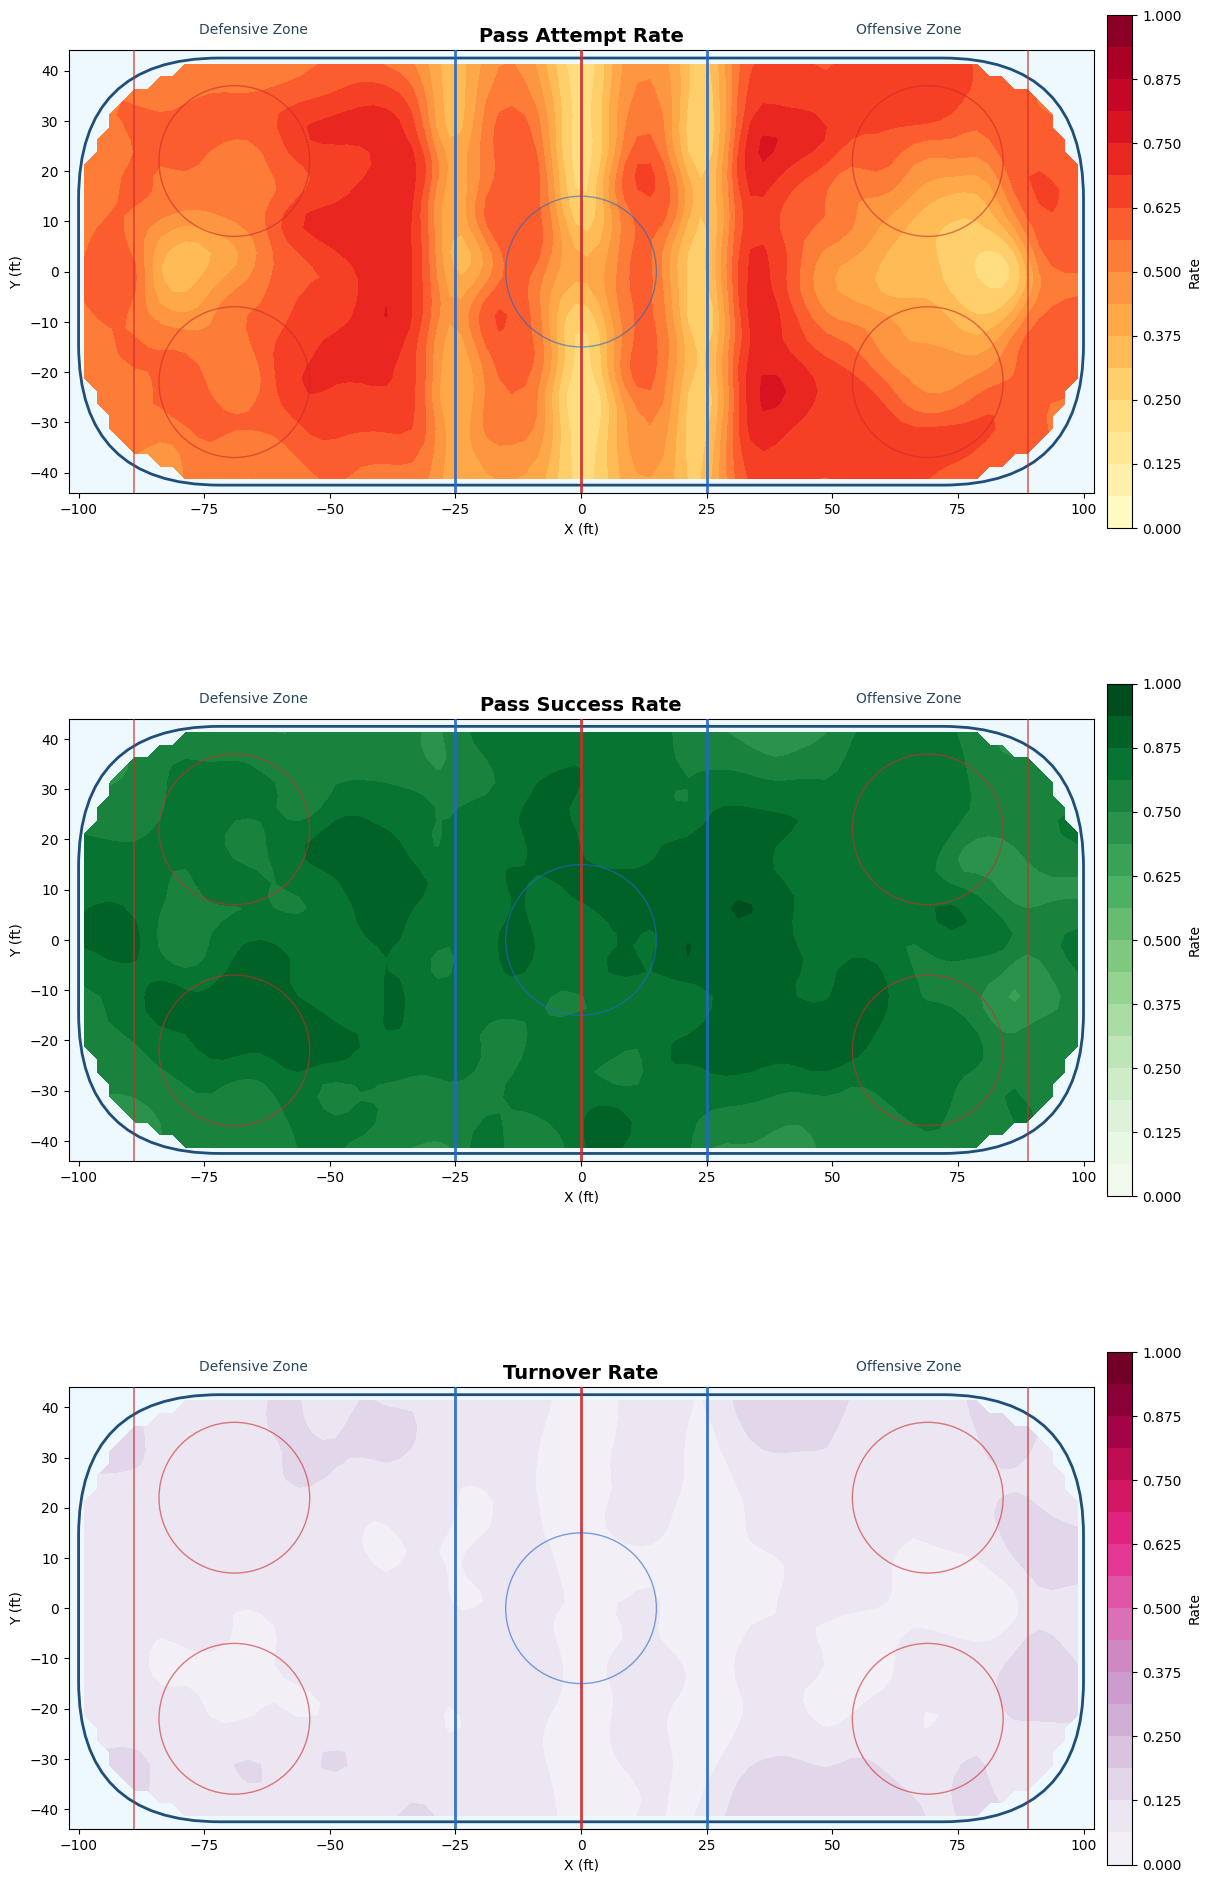

Pass attempts: 22743
Successful passes: 18735
Turnovers: 3931


In [8]:
# Rink KDE maps of pass-attempt rate, pass success rate, and turnover rate.

import matplotlib.pyplot as plt
import matplotlib.patches as patches


if "pm" not in globals():
    raise ValueError("Run the puck-management rating cell first so pm is available.")

# Smaller bins for finer spatial detail.
BIN_SIZE_FT = 2.5
KDE_SIGMA_BINS = 1.6

# Pick coordinate columns available in pm.
coord_pairs = [
    ("x", "y"),
    ("event_x", "event_y"),
    ("x_coord", "y_coord"),
    ("x_location", "y_location"),
]
coord_pair = next(((cx, cy) for cx, cy in coord_pairs if cx in pm.columns and cy in pm.columns), None)
if coord_pair is None:
    raise ValueError(
        "No coordinate columns found in pm. Expected one of: "
        "(x,y), (event_x,event_y), (x_coord,y_coord), (x_location,y_location)."
    )
x_col, y_col = coord_pair

# Build a working frame with spatial and event fields.
h = pm.copy()
h["x"] = pd.to_numeric(h[x_col], errors="coerce")
h["y"] = pd.to_numeric(h[y_col], errors="coerce")
h["game_id"] = pd.to_numeric(h["game_id"], errors="coerce")
h["period"] = pd.to_numeric(h["period"], errors="coerce")
h["event_team_id"] = pd.to_numeric(h["event_team_id"], errors="coerce")
h = h.dropna(subset=["x", "y", "game_id", "period", "event_team_id"]).copy()

# Recompute pass/turnover flags from raw text with case-insensitive matching so this cell is self-contained.
signal_text = (
    h.get("name", "").astype(str).fillna("")
    + " "
    + h.get("type", "").astype(str).fillna("")
    + " "
    + h.get("shorthand", "").astype(str).fillna("")
).str.lower()
outcome_text = h.get("outcome", "").astype(str).fillna("").str.lower()

h["is_pass_attempt_hm"] = signal_text.str.contains("pass", regex=True, na=False)
h["is_pass_success_hm"] = h["is_pass_attempt_hm"] & outcome_text.str.contains(
    "success|complete", regex=True, na=False
)
h["is_turnover_hm"] = (
    h.get("is_possession_breaking", False).fillna(False).astype(bool)
    | (h["is_pass_attempt_hm"] & outcome_text.str.contains("fail|incomplete|broken", regex=True, na=False))
    | outcome_text.str.contains("turnover|lost", regex=True, na=False)
)

# Normalize orientation by game/period/team so offensive zone is always right (x > 0).
shot_mask = signal_text.str.contains(
    r"\bshot\b|wrister|slap\s*shot|snap\s*shot|backhand|tip|deflect",
    regex=True,
    na=False,
)
shot_dirs = (
    h.loc[shot_mask, ["game_id", "period", "event_team_id", "x"]]
    .groupby(["game_id", "period", "event_team_id"], as_index=False)["x"]
    .median()
    .rename(columns={"x": "shot_median_x"})
)
shot_dirs["attack_sign"] = np.sign(shot_dirs["shot_median_x"]).astype(float)
shot_dirs.loc[shot_dirs["attack_sign"] == 0, "attack_sign"] = np.nan

# Fallback when shot rows are sparse: infer direction from offensive-zone events.
if shot_dirs["attack_sign"].isna().any() or shot_dirs.empty:
    oz_dirs = (
        h.loc[h["zone"].astype(str).str.lower().eq("oz"), ["game_id", "period", "event_team_id", "x"]]
        .groupby(["game_id", "period", "event_team_id"], as_index=False)["x"]
        .median()
        .rename(columns={"x": "oz_median_x"})
    )
    oz_dirs["attack_sign_fallback"] = np.sign(oz_dirs["oz_median_x"]).astype(float)
    oz_dirs.loc[oz_dirs["attack_sign_fallback"] == 0, "attack_sign_fallback"] = np.nan
    shot_dirs = shot_dirs.merge(
        oz_dirs[["game_id", "period", "event_team_id", "attack_sign_fallback"]],
        on=["game_id", "period", "event_team_id"],
        how="outer",
    )
    shot_dirs["attack_sign"] = shot_dirs["attack_sign"].fillna(shot_dirs["attack_sign_fallback"])
    shot_dirs = shot_dirs[["game_id", "period", "event_team_id", "attack_sign"]]

h = h.merge(
    shot_dirs,
    on=["game_id", "period", "event_team_id"],
    how="left",
)

zone_lower = h["zone"].astype(str).str.lower().str.strip()
flip_mask = zone_lower.isin(["oz", "dz"]) & h["attack_sign"].lt(0)
h.loc[flip_mask, ["x", "y"]] = -h.loc[flip_mask, ["x", "y"]].to_numpy()

# Keep events inside rectangular bounds first.
h = h[h["x"].between(-100, 100) & h["y"].between(-42.5, 42.5)].copy()

# Rounded-corner rink mask.
absx = h["x"].abs()
absy = h["y"].abs()
center_rect = (absx <= 72) & (absy <= 42.5)
end_strip = (absx > 72) & (absx <= 100) & (absy <= 14.5)
corner_arc = (absx > 72) & (absx <= 100) & (absy > 14.5) & (
    (absx - 72) ** 2 + (absy - 14.5) ** 2 <= 28 ** 2
)
h = h[center_rect | end_strip | corner_arc].copy()
if h.empty:
    raise ValueError("No events with valid rink coordinates after filtering.")

# Fine bins.
x_edges = np.arange(-100, 100 + BIN_SIZE_FT, BIN_SIZE_FT)
y_edges = np.arange(-42.5, 42.5 + BIN_SIZE_FT, BIN_SIZE_FT)
x_mids = (x_edges[:-1] + x_edges[1:]) / 2.0
y_mids = (y_edges[:-1] + y_edges[1:]) / 2.0

h["x_bin"] = pd.cut(h["x"], bins=x_edges, labels=x_mids, include_lowest=True)
h["y_bin"] = pd.cut(h["y"], bins=y_edges, labels=y_mids, include_lowest=True)
h = h.dropna(subset=["x_bin", "y_bin"]).copy()

cell_stats = (
    h.groupby(["y_bin", "x_bin"], observed=True, as_index=False)
    .agg(
        total_events=("x", "size"),
        pass_attempts=("is_pass_attempt_hm", "sum"),
        pass_successes=("is_pass_success_hm", "sum"),
        turnovers=("is_turnover_hm", "sum"),
    )
)
cell_stats["pass_attempt_rate"] = (
    cell_stats["pass_attempts"] / cell_stats["total_events"].replace(0, np.nan)
).clip(0, 1)
cell_stats["pass_success_rate"] = (
    cell_stats["pass_successes"] / cell_stats["pass_attempts"].replace(0, np.nan)
).clip(0, 1)
cell_stats["turnover_rate"] = (
    cell_stats["turnovers"] / cell_stats["total_events"].replace(0, np.nan)
).clip(0, 1)

def gaussian_kernel_1d(sigma_bins: float):
    radius = int(np.ceil(3 * sigma_bins))
    x = np.arange(-radius, radius + 1, dtype=float)
    k = np.exp(-(x ** 2) / (2 * sigma_bins ** 2))
    return k / k.sum()

def smooth_2d(arr: np.ndarray, sigma_bins: float):
    kernel = gaussian_kernel_1d(sigma_bins)
    sm = np.apply_along_axis(lambda row: np.convolve(row, kernel, mode="same"), axis=1, arr=arr)
    sm = np.apply_along_axis(lambda col: np.convolve(col, kernel, mode="same"), axis=0, arr=sm)
    return sm

# KDE-style smoothed rates: smooth weighted events and smooth total events, then divide.
counts, _, _ = np.histogram2d(h["y"], h["x"], bins=[y_edges, x_edges])
pass_w, _, _ = np.histogram2d(h["y"], h["x"], bins=[y_edges, x_edges], weights=h["is_pass_attempt_hm"].astype(float))
succ_w, _, _ = np.histogram2d(h["y"], h["x"], bins=[y_edges, x_edges], weights=h["is_pass_success_hm"].astype(float))
turn_w, _, _ = np.histogram2d(h["y"], h["x"], bins=[y_edges, x_edges], weights=h["is_turnover_hm"].astype(float))

counts_sm = smooth_2d(counts, KDE_SIGMA_BINS)
pass_sm = smooth_2d(pass_w, KDE_SIGMA_BINS)
succ_sm = smooth_2d(succ_w, KDE_SIGMA_BINS)
turn_sm = smooth_2d(turn_w, KDE_SIGMA_BINS)

pass_attempt_kde = np.divide(pass_sm, counts_sm, out=np.full_like(pass_sm, np.nan), where=counts_sm > 0)
pass_success_kde = np.divide(succ_sm, pass_sm, out=np.full_like(succ_sm, np.nan), where=pass_sm > 0)
turnover_kde = np.divide(turn_sm, counts_sm, out=np.full_like(turn_sm, np.nan), where=counts_sm > 0)

pass_attempt_kde = np.clip(pass_attempt_kde, 0, 1)
pass_success_kde = np.clip(pass_success_kde, 0, 1)
turnover_kde = np.clip(turnover_kde, 0, 1)

# Build mask for bins outside rounded-corner rink shape.
Xc, Yc = np.meshgrid(x_mids, y_mids)
absX = np.abs(Xc)
absY = np.abs(Yc)
inside = (
    ((absX <= 72) & (absY <= 42.5))
    | ((absX > 72) & (absX <= 100) & (absY <= 14.5))
    | ((absX > 72) & (absX <= 100) & (absY > 14.5) & (((absX - 72) ** 2 + (absY - 14.5) ** 2) <= 28 ** 2))
)

pass_attempt_arr = np.ma.masked_array(pass_attempt_kde, mask=~inside | np.isnan(pass_attempt_kde))
pass_success_arr = np.ma.masked_array(pass_success_kde, mask=~inside | np.isnan(pass_success_kde))
turnover_arr = np.ma.masked_array(turnover_kde, mask=~inside | np.isnan(turnover_kde))

def draw_rink(ax):
    ax.set_facecolor("#eef8ff")
    rink = patches.FancyBboxPatch(
        (-100, -42.5),
        200,
        85,
        boxstyle=patches.BoxStyle("Round", pad=0.0, rounding_size=28),
        linewidth=2.0,
        edgecolor="#1f4e79",
        facecolor="none",
        zorder=5,
    )
    ax.add_patch(rink)
    ax.axvline(0, color="#cc2b2b", linewidth=2.0, alpha=0.9, zorder=6)
    ax.axvline(-25, color="#2367c9", linewidth=2.0, alpha=0.9, zorder=6)
    ax.axvline(25, color="#2367c9", linewidth=2.0, alpha=0.9, zorder=6)
    ax.axvline(-89, color="#cc2b2b", linewidth=1.2, alpha=0.7, zorder=6)
    ax.axvline(89, color="#cc2b2b", linewidth=1.2, alpha=0.7, zorder=6)
    for cx in (-69, 69):
        for cy in (-22, 22):
            ax.add_patch(
                patches.Circle((cx, cy), radius=15, fill=False, ec="#cc2b2b", lw=1.0, alpha=0.6, zorder=6)
            )
    ax.add_patch(patches.Circle((0, 0), radius=15, fill=False, ec="#2367c9", lw=1.0, alpha=0.6, zorder=6))
    ax.set_xlim(-102, 102)
    ax.set_ylim(-44, 44)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X (ft)")
    ax.set_ylabel("Y (ft)")

def add_zone_labels(ax):
    ax.text(0.18, 1.03, "Defensive Zone", transform=ax.transAxes, ha="center", va="bottom", fontsize=10, color="#29465b")
    ax.text(0.82, 1.03, "Offensive Zone", transform=ax.transAxes, ha="center", va="bottom", fontsize=10, color="#29465b")

# 3-panel vertical stack with KDE-style contours and distinct colormaps.
fig, axes = plt.subplots(3, 1, figsize=(12, 20), constrained_layout=True)
levels = np.linspace(0, 1, 17)

m0 = axes[0].contourf(Xc, Yc, pass_attempt_arr, levels=levels, cmap="YlOrRd", vmin=0, vmax=1, zorder=1)
draw_rink(axes[0])
add_zone_labels(axes[0])
axes[0].set_title("Pass Attempt Rate", fontsize=14, fontweight="bold")
fig.colorbar(m0, ax=axes[0], fraction=0.025, pad=0.01, label="Rate")

m1 = axes[1].contourf(Xc, Yc, pass_success_arr, levels=levels, cmap="Greens", vmin=0, vmax=1, zorder=1)
draw_rink(axes[1])
add_zone_labels(axes[1])
axes[1].set_title("Pass Success Rate", fontsize=14, fontweight="bold")
fig.colorbar(m1, ax=axes[1], fraction=0.025, pad=0.01, label="Rate")

m2 = axes[2].contourf(Xc, Yc, turnover_arr, levels=levels, cmap="PuRd", vmin=0, vmax=1, zorder=1)
draw_rink(axes[2])
add_zone_labels(axes[2])
axes[2].set_title("Turnover Rate", fontsize=14, fontweight="bold")
fig.colorbar(m2, ax=axes[2], fraction=0.025, pad=0.01, label="Rate")

plt.show()

flip_share = float(flip_mask.mean()) if len(h) else 0.0
direction_cov = float(h["attack_sign"].notna().mean()) if len(h) else 0.0
print("Pass attempts:", int(h["is_pass_attempt_hm"].sum()))
print("Successful passes:", int(h["is_pass_success_hm"].sum()))
print("Turnovers:", int(h["is_turnover_hm"].sum()))

## Extending the puck-management model

The rating above (`PuckManagement+`) is built from four hand-weighted rates (pass efficiency,
turnover rate, loose-puck-recovery rate, dump-in success). It's a reasonable first cut, but the
weights (0.40 / 0.35 / 0.15 / 0.10) are asserted, not derived, and it ignores two things the data
actually supports:

1. **Zone entries/exits.** Sportlogiq tags controlled carries and passes into/out of each zone
   separately from dump-ins/outs (`CONTROLLED ENTRY INTO OZ`, `CONTROLLED EXIT FROM DZ`, `OZ ENTRY
   PASS`, `DZ OUTLET PASS`, in the `shorthand` column). This is the standard "did you keep
   possession through the neutral zone" metric in hockey analytics, and it's directly tagged in
   this dataset rather than something we have to infer.
2. **Where on the ice puck management actually matters.** A turnover at the offensive blue line
   is not the same as a turnover in the neutral zone — the first one usually just costs you a
   zone entry, the second can be a odd-man rush against. The cells below build a simple
   *expected possession value* (xT-style) surface from the 18 games' worth of possession chains,
   so a player's passes/carries are credited for moving the puck into more dangerous ice and
   debited for turning it over in proportion to the value that was actually at stake.

Both are combined with the original rate stats into a single percentile-based scorecard at the
end, instead of one more arbitrarily-weighted formula.

### Zone entries and exits (controlled vs. dumped)

For each player: of all their attempts to move the puck out of the defensive zone (controlled
carry/pass exit, failed outlet pass, or dump-out), what share were **controlled**? Same question
for entries into the offensive zone. Controlled entries/exits are well established in hockey
analytics (Eric Tulsky et al.) to generate roughly double the shot rate of dumped ones, so this is
a direct, data-native measure of "how the game is controlled" independent of the xT model below.

In [9]:
# Zone entries & exits, using Sportlogiq's own event tagging rather than a distance/zone
# heuristic, so this reflects the data provider's own possession-quality calls.
# NOTE: pm's text columns (including shorthand) were lowercased earlier in the notebook, so
# match against the uppercased version here rather than assuming the raw-data casing.
sh = pm["shorthand"].astype(str).str.upper()
nm = pm["name"].astype(str)
oc = pm["outcome"].astype(str)

pm["is_controlled_exit"] = (
    sh.str.contains("CONTROLLED EXIT", na=False)
    | (sh.str.contains("DZ OUTLET PASS", na=False) & oc.eq("successful"))
    | sh.eq("DZ REC FACE OFF+EXIT")
)
pm["is_failed_exit"] = sh.str.contains("DZ OUTLET PASS", na=False) & oc.eq("failed")
pm["is_dumpout"] = nm.eq("dumpout")
pm["is_exit_attempt"] = pm["is_controlled_exit"] | pm["is_failed_exit"] | pm["is_dumpout"]

pm["is_controlled_entry"] = (
    (sh.str.contains("ENTRY INTO OZ", na=False) & ~sh.str.contains("AGAINST", na=False))
    | (sh.str.contains("OZ ENTRY PASS", na=False) & oc.eq("successful"))
    | sh.eq("NZ REC FACE OFF+ENTRY")
)
pm["is_failed_entry"] = sh.str.contains("OZ ENTRY PASS", na=False) & oc.eq("failed")
pm["is_dumpin"] = nm.eq("dumpin")
pm["is_entry_attempt"] = pm["is_controlled_entry"] | pm["is_failed_entry"] | pm["is_dumpin"]

# Sanity check: these subsets should be mutually exclusive within each attempt type.
assert not (pm["is_controlled_exit"] & pm["is_failed_exit"]).any()
assert not (pm["is_controlled_exit"] & pm["is_dumpout"]).any()
assert not (pm["is_controlled_entry"] & pm["is_dumpin"]).any()
assert not (pm["is_controlled_entry"] & pm["is_failed_entry"]).any()
assert pm["is_controlled_exit"].sum() > 0, "no controlled exits matched -- check shorthand casing"
assert pm["is_controlled_entry"].sum() > 0, "no controlled entries matched -- check shorthand casing"

entry_exit = (
    pm.groupby(["event_team_id", "player_jersey"], as_index=False)
    .agg(
        exit_attempts=("is_exit_attempt", "sum"),
        controlled_exits=("is_controlled_exit", "sum"),
        entry_attempts=("is_entry_attempt", "sum"),
        controlled_entries=("is_controlled_entry", "sum"),
    )
)
entry_exit["controlled_exit_pct"] = (
    entry_exit["controlled_exits"] / entry_exit["exit_attempts"].replace(0, np.nan)
).clip(0, 1)
entry_exit["controlled_entry_pct"] = (
    entry_exit["controlled_entries"] / entry_exit["entry_attempts"].replace(0, np.nan)
).clip(0, 1)

entry_exit = entry_exit.merge(player_names, on=["event_team_id", "player_jersey"], how="left")
entry_exit["player_name"] = (
    entry_exit["first_name"].fillna("").str.strip() + " " + entry_exit["last_name"].fillna("").str.strip()
).str.strip()
entry_exit = entry_exit.merge(team_labels, on="event_team_id", how="left")

MIN_EXIT_ATTEMPTS = 10
MIN_ENTRY_ATTEMPTS = 10

league_exit_pct = pm["is_controlled_exit"].sum() / pm["is_exit_attempt"].sum()
league_entry_pct = pm["is_controlled_entry"].sum() / pm["is_entry_attempt"].sum()
print(f"League-wide controlled exit rate: {pm['is_controlled_exit'].sum():,} / {pm['is_exit_attempt'].sum():,} = {league_exit_pct:.1%}")
print(f"League-wide controlled entry rate: {pm['is_controlled_entry'].sum():,} / {pm['is_entry_attempt'].sum():,} = {league_entry_pct:.1%}")

print(f"\nTop 15 controlled exit rate (min {MIN_EXIT_ATTEMPTS} exit attempts):")
display(
    entry_exit[entry_exit["exit_attempts"] >= MIN_EXIT_ATTEMPTS]
    .sort_values("controlled_exit_pct", ascending=False)
    [["player_name", "team_abbr", "player_jersey", "exit_attempts", "controlled_exits", "controlled_exit_pct"]]
    .head(15)
)

print(f"\nTop 15 controlled entry rate (min {MIN_ENTRY_ATTEMPTS} entry attempts):")
display(
    entry_exit[entry_exit["entry_attempts"] >= MIN_ENTRY_ATTEMPTS]
    .sort_values("controlled_entry_pct", ascending=False)
    [["player_name", "team_abbr", "player_jersey", "entry_attempts", "controlled_entries", "controlled_entry_pct"]]
    .head(15)
)

League-wide controlled exit rate: 2,946 / 4,844 = 60.8%
League-wide controlled entry rate: 1,380 / 2,432 = 56.7%

Top 15 controlled exit rate (min 10 exit attempts):


,player_name,team_abbr,player_jersey,exit_attempts,controlled_exits,controlled_exit_pct
30,Nathan Bastian,DAL,11,10,9,0.900000
125,Elias Lindholm,BOS,28,10,9,0.900000
68,John Tavares,TOR,91,17,15,0.882353
138,David Pastrnak,BOS,88,24,21,0.875000
148,Michael Rasmussen,DET,27,29,25,0.862069
136,Ivan Ivan,BOS,82,14,12,0.857143
56,Bo Groulx,TOR,29,42,36,0.857143
63,Henrik Rybinski,TOR,58,33,28,0.848485
131,Matthew Poitras,BOS,51,32,26,0.812500
69,Vinni Lettieri,TOR,95,37,30,0.810811



Top 15 controlled entry rate (min 10 entry attempts):


,player_name,team_abbr,player_jersey,entry_attempts,controlled_entries,controlled_entry_pct
100,Alex Barre-Boulet,COL,27,21,19,0.904762
97,Nicolas Roy,COL,10,19,17,0.894737
58,Auston Matthews,TOR,34,18,16,0.888889
130,Jonathan Aspirot,BOS,45,17,14,0.823529
5,Sebastian Aho,CAR,20,38,31,0.815789
88,Max Jones,EDM,46,19,15,0.789474
108,Gavin Brindley,COL,54,35,27,0.771429
14,Jordan Martinook,CAR,48,26,20,0.769231
78,Adam Henrique,EDM,19,17,13,0.764706
68,John Tavares,TOR,91,12,9,0.750000


### Expected Possession Value (EPV): a lightweight zone-value model

For each of the 18 games, chain consecutive play-by-play events into **possessions** (a chain
ends wherever `is_last_play_of_possession` is `True`). For each of Sportlogiq's 22 named ice
zones (`play_section` — e.g. `innerSlot`, `eastPointDZ`), compute the empirical probability that a
possession touching that zone eventually produces a shot attempt for the possessing team. That
probability is the zone's **xT** ("expected threat") value — this is the same idea as Karun
Singh's Expected Threat model used in soccer analytics, adapted to hockey's zone/possession
structure instead of a pitch grid.

A player's **EPV added** on a given touch is `xT(zone of the next touch in the possession) -
xT(zone of this touch)` — did their pass/carry move the puck to more dangerous ice? A turnover
that ends the possession is debited the zone's full xT value, since the team forfeits whatever
threat had been built up. This is zero-sum by construction: what one player's touch adds, either
the next zone's value reflects it or an opponent's turnover-forcing play takes it away.

**Caveat, stated plainly:** this rewards puck *progression* — carrying/passing the puck out of
low-value ice — more than it rewards finishing plays in already-dangerous ice, because a shot
itself isn't credited any further zone gain. In practice this means puck-moving defensemen tend
to rank well and high-usage forwards who mostly receive the puck deep in the offensive zone (where
xT is already high, so there's little marginal value left to add, and a turnover there is costly)
tend to rank worse. That's a known property of xT-style models, not a bug — it's why we use it
alongside pass efficiency, turnover rate, and entry/exit rates below rather than on its own.

In [10]:
# IMPORTANT: chain/possession structure has to be built from the full, unfiltered play-by-play
# stream in true chronological order -- pm already dropped every row that isn't a qualifying
# touch (is_poss_event), and doing the shift/cumsum chain logic on that filtered frame would
# silently treat non-adjacent events as consecutive. So we rebuild the event_team_id resolution
# on the complete pbp_df here (reusing the same helper from the ratings cell above) and only
# restrict to attributable player touches at the very end, after chains are already correct.
full = pbp_df.copy()
full["game_id"] = pd.to_numeric(full["game_id"], errors="coerce").astype("Int64")
full = full.merge(game_meta, on="game_id", how="left")
full["event_team_text"] = full["event_team"].astype(str).str.strip().str.upper()
full["home_abbr"] = full["home_abbr"].astype(str).str.strip().str.upper()
full["away_abbr"] = full["away_abbr"].astype(str).str.strip().str.upper()
full["event_team_id"] = full.apply(_resolve_event_team_id, axis=1)
full["event_team_id"] = pd.to_numeric(full["event_team_id"], errors="coerce").astype("Int64")
full["player_jersey"] = pd.to_numeric(full["player_id"], errors="coerce").astype("Int64")
full["game_time"] = pd.to_numeric(full["game_time"], errors="coerce").astype(float)
full["period"] = pd.to_numeric(full["period"], errors="coerce").astype("Int64")
for c in ["name", "shorthand", "outcome", "zone", "play_section"]:
    full[c] = full[c].astype(str).str.lower().str.strip()

work = full.sort_values(["game_id", "period", "game_time"]).reset_index(drop=True).copy()
work["is_turnover_epv"] = work["is_possession_breaking"].fillna(False).astype(bool)

# Possession chains: a new chain starts right after the previous row ended one.
work["prev_last"] = work.groupby(["game_id", "period"])["is_last_play_of_possession"].shift(1).fillna(False).astype(bool)
work["possession_id"] = work.groupby(["game_id", "period"])["prev_last"].cumsum()
work["chain_key"] = list(zip(work["game_id"], work["period"], work["possession_id"]))

work["is_shot_row"] = work["name"].isin(["shot", "goal"])
chain_team = work.groupby("chain_key")["event_team_id"].agg(lambda s: s.dropna().mode().iat[0] if s.dropna().size else pd.NA)
shot_rows = work[work["is_shot_row"]]
chain_has_shot = shot_rows.groupby("chain_key").apply(
    lambda g: bool((g["event_team_id"] == chain_team.get(g.name)).any())
)
work["chain_has_shot"] = work["chain_key"].map(chain_has_shot).fillna(False)
work["is_team_row"] = work["event_team_id"] == work["chain_key"].map(chain_team)

# xT(zone): fit only on the possessing team's own touches, so opponent pressure/block events
# inside the same chain don't dilute the estimate.
xt_by_section = work.loc[work["is_team_row"]].groupby("play_section")["chain_has_shot"].mean()
global_xt = work.loc[work["is_team_row"], "chain_has_shot"].mean()
work["xt"] = work["play_section"].map(xt_by_section).fillna(global_xt)

work["next_xt_in_chain"] = work.groupby("chain_key")["xt"].shift(-1)
work["is_last_in_chain"] = work["next_xt_in_chain"].isna()
work["epv_delta"] = np.where(
    work["is_last_in_chain"],
    np.where(work["is_turnover_epv"], -work["xt"], 0.0),
    work["next_xt_in_chain"] - work["xt"],
)
work.loc[~work["is_team_row"], "epv_delta"] = np.nan

print(f"Total events (full, unfiltered): {len(work):,}")
print(f"Possession chains identified: {work['chain_key'].nunique():,}")
print(f"Chains ending in a shot attempt for the possessing team: {int(pd.Series(chain_has_shot).sum()):,}")
print("\nxT value by ice zone (P(possession ends in a shot) | a touch happened here), highest to lowest:")
print(xt_by_section.sort_values(ascending=False).round(3).to_string())

# Attribute EPV only to rows that are actual player touches (has jersey + resolved team) --
# this is where we finally apply the same restriction pm used, but after chains were already
# built correctly on the full timeline.
attributable = work.dropna(subset=["epv_delta", "player_jersey", "event_team_id"])
player_epv = (
    attributable.groupby(["event_team_id", "player_jersey"], as_index=False)
    .agg(epv_added=("epv_delta", "sum"), epv_touches=("epv_delta", "size"))
)
player_epv["epv_per_touch"] = player_epv["epv_added"] / player_epv["epv_touches"]
player_epv = player_epv.merge(player_names, on=["event_team_id", "player_jersey"], how="left")
player_epv["player_name"] = (
    player_epv["first_name"].fillna("").str.strip() + " " + player_epv["last_name"].fillna("").str.strip()
).str.strip()
player_epv = player_epv.merge(team_labels, on="event_team_id", how="left")

MIN_EPV_TOUCHES = 20
epv_eligible = player_epv[player_epv["epv_touches"] >= MIN_EPV_TOUCHES].sort_values("epv_per_touch", ascending=False)

print(f"\nTop 15 by EPV added per touch (min {MIN_EPV_TOUCHES} touches):")
display(epv_eligible[["player_name", "team_abbr", "player_jersey", "epv_touches", "epv_added", "epv_per_touch"]].head(15))
print(f"\nBottom 15 by EPV added per touch (min {MIN_EPV_TOUCHES} touches):")
display(epv_eligible[["player_name", "team_abbr", "player_jersey", "epv_touches", "epv_added", "epv_per_touch"]].tail(15))

team_epv = (
    attributable.groupby("event_team_id", as_index=False)
    .agg(epv_added=("epv_delta", "sum"), epv_touches=("epv_delta", "size"))
    .merge(team_labels, on="event_team_id", how="left")
)
team_epv["epv_per_touch"] = team_epv["epv_added"] / team_epv["epv_touches"]
print("\nTeam-level EPV:")
display(team_epv.sort_values("epv_per_touch", ascending=False)[["team_abbr", "epv_touches", "epv_added", "epv_per_touch"]])

C:\Users\Connor\AppData\Local\Temp\ipykernel_10428\3331768964.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work["prev_last"] = work.groupby(["game_id", "period"])["is_last_play_of_possession"].shift(1).fillna(False).astype(bool)


Total events (full, unfiltered): 63,456
Possession chains identified: 9,818
Chains ending in a shot attempt for the possessing team: 1,866

xT value by ice zone (P(possession ends in a shot) | a touch happened here), highest to lowest:
play_section
innerslot             0.796
eastouterslot         0.751
westouterslot         0.684
centerpoint           0.613
eastpoint             0.459
westpoint             0.454
none                  0.434
outsidenortheast      0.431
outsidenorthwest      0.417
northcenternz         0.257
southcenternz         0.250
northwestboardsnz     0.173
southeastboardsnz     0.160
northeastboardsnz     0.158
centerpointdz         0.150
southwestboardsnz     0.142
eastpointdz           0.128
westpointdz           0.115
eastouterslotdz       0.113
westouterslotdz       0.104
outsidenorthwestdz    0.087
outsidenortheastdz    0.085
innerslotdz           0.080

Top 15 by EPV added per touch (min 20 touches):


C:\Users\Connor\AppData\Local\Temp\ipykernel_10428\3331768964.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chain_has_shot = shot_rows.groupby("chain_key").apply(
C:\Users\Connor\AppData\Local\Temp\ipykernel_10428\3331768964.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work["chain_has_shot"] = work["chain_key"].map(chain_has_shot).fillna(False)


,player_name,team_abbr,player_jersey,epv_touches,epv_added,epv_per_touch
85,Tristan Jarry,EDM,35,33,2.210617,0.066988
86,Connor Ingram,EDM,39,27,1.674061,0.062002
71,Josh Brown,EDM,4,181,7.535283,0.041631
128,Jordan Harris,BOS,43,67,2.647406,0.039514
90,Vincent Desharnais,EDM,73,138,4.947515,0.035852
21,Jaccob Slavin,CAR,74,52,1.743961,0.033538
151,John Gibson,DET,36,31,1.013758,0.032702
160,Simon Edvinsson,DET,77,180,5.153583,0.028631
142,Albert Johansson,DET,20,163,4.627346,0.028389
165,Ben Hutton,VGK,17,263,7.069042,0.026878



Bottom 15 by EPV added per touch (min 20 touches):


,player_name,team_abbr,player_jersey,epv_touches,epv_added,epv_per_touch
14,Jordan Martinook,CAR,48,311,-12.493440,-0.040172
52,Calle Jarnkrok,TOR,19,582,-23.755073,-0.040816
13,Andrei Svechnikov,CAR,37,304,-12.417119,-0.040846
164,Jack Eichel,VGK,9,233,-9.702465,-0.041641
58,Auston Matthews,TOR,34,310,-13.499167,-0.043546
11,William Carrier,CAR,28,719,-32.382255,-0.045038
20,Taylor Hall,CAR,71,393,-18.863437,-0.047999
125,Elias Lindholm,BOS,28,127,-6.241079,-0.049142
113,Nazem Kadri,COL,91,62,-3.099152,-0.049986
136,Ivan Ivan,BOS,82,252,-13.076283,-0.051890



Team-level EPV:


,team_abbr,epv_touches,epv_added,epv_per_touch
6,DET,3284,26.896733,0.008190
3,EDM,5094,0.332277,0.000065
5,BOS,5035,-49.924361,-0.009915
4,COL,6439,-80.988543,-0.012578
2,TOR,7990,-117.766192,-0.014739
1,DAL,5199,-98.063420,-0.018862
7,VGK,6944,-135.435215,-0.019504
0,CAR,7702,-164.074133,-0.021303


### Zone-value surface (visual)

The same idea as the pass/turnover heatmaps above, but for xT: at fine spatial resolution
(2.5 ft bins, smoothed), what's the probability that a touch at this exact spot on the ice is
part of a possession that ends in a shot attempt? This should mirror hockey intuition — value
rising sharply toward the slot — which is a useful sanity check on the possession-chain model
before trusting the player-level numbers above.

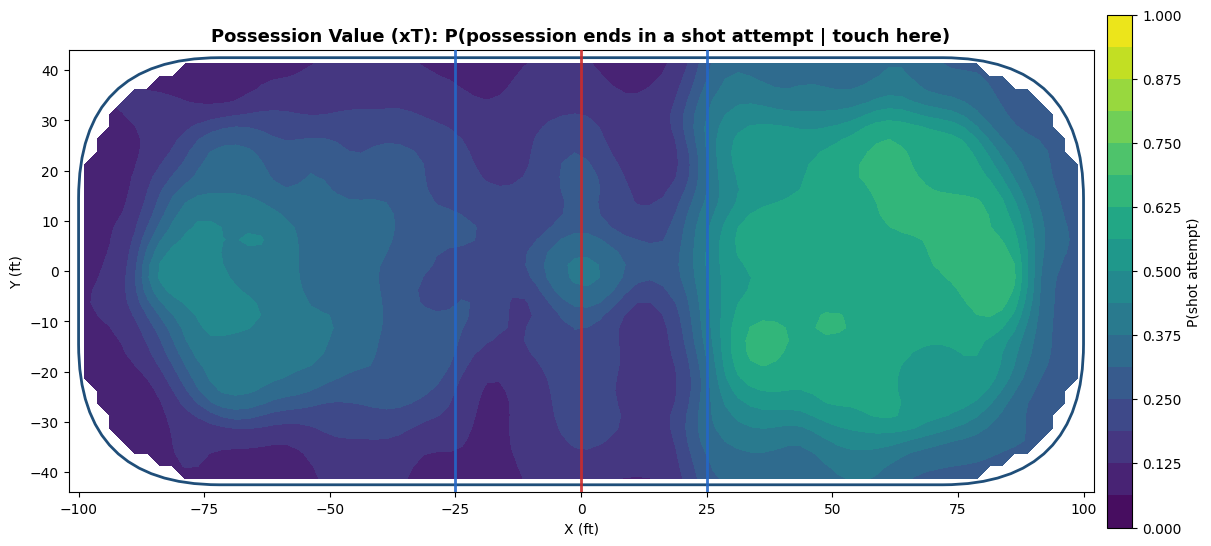

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BIN_SIZE_FT2 = 2.5
KDE_SIGMA_BINS2 = 1.6

hv = work.dropna(subset=["x_adj_coord", "y_adj_coord"]).copy()
hv["x"] = pd.to_numeric(hv["x_adj_coord"], errors="coerce")
hv["y"] = pd.to_numeric(hv["y_adj_coord"], errors="coerce")
hv = hv.dropna(subset=["x", "y"])
hv = hv[hv["x"].between(-100, 100) & hv["y"].between(-42.5, 42.5)]

absx, absy = hv["x"].abs(), hv["y"].abs()
inside_rows = (
    ((absx <= 72) & (absy <= 42.5))
    | ((absx > 72) & (absx <= 100) & (absy <= 14.5))
    | ((absx > 72) & (absx <= 100) & (absy > 14.5) & ((absx - 72) ** 2 + (absy - 14.5) ** 2 <= 28 ** 2))
)
hv = hv[inside_rows]

x_edges2 = np.arange(-100, 100 + BIN_SIZE_FT2, BIN_SIZE_FT2)
y_edges2 = np.arange(-42.5, 42.5 + BIN_SIZE_FT2, BIN_SIZE_FT2)
x_mids2 = (x_edges2[:-1] + x_edges2[1:]) / 2.0
y_mids2 = (y_edges2[:-1] + y_edges2[1:]) / 2.0

counts2, _, _ = np.histogram2d(hv["y"], hv["x"], bins=[y_edges2, x_edges2])
shot2, _, _ = np.histogram2d(hv["y"], hv["x"], bins=[y_edges2, x_edges2], weights=hv["chain_has_shot"].astype(float))


def _gk1d(sigma_bins):
    radius = int(np.ceil(3 * sigma_bins))
    xk = np.arange(-radius, radius + 1, dtype=float)
    k = np.exp(-(xk ** 2) / (2 * sigma_bins ** 2))
    return k / k.sum()


def _smooth2d(arr, sigma_bins):
    kernel = _gk1d(sigma_bins)
    sm = np.apply_along_axis(lambda row: np.convolve(row, kernel, mode="same"), axis=1, arr=arr)
    sm = np.apply_along_axis(lambda col: np.convolve(col, kernel, mode="same"), axis=0, arr=sm)
    return sm


counts_sm2 = _smooth2d(counts2, KDE_SIGMA_BINS2)
shot_sm2 = _smooth2d(shot2, KDE_SIGMA_BINS2)
xt_kde = np.divide(shot_sm2, counts_sm2, out=np.full_like(shot_sm2, np.nan), where=counts_sm2 > 5)
xt_kde = np.clip(xt_kde, 0, 1)

Xc2, Yc2 = np.meshgrid(x_mids2, y_mids2)
absX2, absY2 = np.abs(Xc2), np.abs(Yc2)
inside2 = (
    ((absX2 <= 72) & (absY2 <= 42.5))
    | ((absX2 > 72) & (absX2 <= 100) & (absY2 <= 14.5))
    | ((absX2 > 72) & (absX2 <= 100) & (absY2 > 14.5) & (((absX2 - 72) ** 2 + (absY2 - 14.5) ** 2) <= 28 ** 2))
)
xt_arr = np.ma.masked_array(xt_kde, mask=~inside2 | np.isnan(xt_kde))

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
m = ax.contourf(Xc2, Yc2, xt_arr, levels=np.linspace(0, 1, 17), cmap="viridis", vmin=0, vmax=1, zorder=1)
rink = patches.FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle=patches.BoxStyle("Round", pad=0.0, rounding_size=28),
    linewidth=2.0, edgecolor="#1f4e79", facecolor="none", zorder=5,
)
ax.add_patch(rink)
ax.axvline(0, color="#cc2b2b", linewidth=2.0, alpha=0.9, zorder=6)
ax.axvline(-25, color="#2367c9", linewidth=2.0, alpha=0.9, zorder=6)
ax.axvline(25, color="#2367c9", linewidth=2.0, alpha=0.9, zorder=6)
ax.set_xlim(-102, 102)
ax.set_ylim(-44, 44)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("X (ft)")
ax.set_ylabel("Y (ft)")
ax.set_title("Possession Value (xT): P(possession ends in a shot attempt | touch here)", fontsize=13, fontweight="bold")
fig.colorbar(m, ax=ax, fraction=0.025, pad=0.01, label="P(shot attempt)")
plt.show()

### Composite scorecard

Instead of one more hand-picked weighted formula, rank every eligible player by **percentile**
within a set of independent puck-management dimensions, then average the percentiles. A player
who is merely average on every dimension scores 50; a player who is top-decile on all of them
scores ~90+.

Forwards and defense are scored on the same five dimensions -- pass efficiency, turnover rate
(inverted), EPV added per touch, controlled exit rate, controlled entry rate -- but percentiled
**separately within each position group**, not pooled together. A forward and a defenseman have
structurally different zone weighting and touch profiles (forwards drive zone entries, defense
drive zone exits), so a shared percentile pool would mostly measure position rather than skill.

Goalies get their own, smaller scorecard: **breakout/outlet pass success** and **controlled-exit
contribution** only. Controlled-entry rate and EPV-added are built around forward/defense zone
progression and are not meaningful for a goalie, who essentially never carries the puck into the
offensive zone -- what matters for a goalie's puck management is whether their puck play (playing
it behind the net, an outlet pass to a breaking defenseman) actually starts a controlled exit
rather than a turnover.


In [12]:
MIN_TOUCHES_FINAL = 20
MIN_TOUCHES_GOALIE_FINAL = 10  # goalies see far fewer qualifying puck touches per game than skaters

dash = player_ratings[[
    "event_team_id", "player_jersey", "player_name", "team_abbr", "touches", "position_group",
    "pass_eff", "turnover_rate", "lpr_rate", "dump_success_rate",
]].copy()

dash = dash.merge(
    entry_exit[["event_team_id", "player_jersey", "exit_attempts", "controlled_exit_pct",
                "entry_attempts", "controlled_entry_pct"]],
    on=["event_team_id", "player_jersey"], how="left",
)
dash = dash.merge(
    player_epv[["event_team_id", "player_jersey", "epv_touches", "epv_added", "epv_per_touch"]],
    on=["event_team_id", "player_jersey"], how="left",
)


def pct_rank(s, ascending=True):
    return s.rank(pct=True, ascending=ascending) * 100


def group_pct_rank(df, group_col, value_col, ascending=True):
    return df.groupby(group_col)[value_col].transform(lambda s: pct_rank(s, ascending=ascending))


# Forwards and defense: the same five puck-management dimensions as before (pass efficiency,
# turnover rate, EPV added per touch, controlled exit%, controlled entry%), but percentiled
# separately within each position group instead of pooled -- a forward and a defenseman have
# structurally different zone weighting and entry/exit volume, so a shared percentile pool
# mostly just measures "is this a forward" rather than skill.
skaters = dash[dash["position_group"].isin(["F", "D"])].copy()
skaters = skaters[skaters["touches"] >= MIN_TOUCHES_FINAL].copy()

skaters["pct_pass_eff"] = group_pct_rank(skaters, "position_group", "pass_eff", ascending=True)
skaters["pct_turnover"] = group_pct_rank(skaters, "position_group", "turnover_rate", ascending=False)
skaters["pct_epv"] = group_pct_rank(skaters, "position_group", "epv_per_touch", ascending=True)
skaters["pct_exit"] = group_pct_rank(skaters, "position_group", "controlled_exit_pct", ascending=True)
skaters["pct_entry"] = group_pct_rank(skaters, "position_group", "controlled_entry_pct", ascending=True)

pct_cols = ["pct_pass_eff", "pct_turnover", "pct_epv", "pct_exit", "pct_entry"]
skaters["PuckControlScore"] = skaters[pct_cols].mean(axis=1, skipna=True)
skaters["dimensions_available"] = skaters[pct_cols].notna().sum(axis=1)

final = skaters.sort_values(["position_group", "PuckControlScore"], ascending=[True, False]).reset_index(drop=True)

display_cols = ["player_name", "team_abbr", "touches", "pass_eff", "turnover_rate", "epv_per_touch",
                 "controlled_exit_pct", "controlled_entry_pct", "PuckControlScore", "dimensions_available"]

print(f"Skaters scored: {len(final)} (min {MIN_TOUCHES_FINAL} touches, ranked within forwards / defense separately)")
for grp, label in [("F", "Forwards"), ("D", "Defense")]:
    grp_df = final[final["position_group"] == grp]
    print(f"\nTop 15 -- {label} Puck Control Score:")
    display(grp_df[display_cols].head(15))
    print(f"\nBottom 15 -- {label} Puck Control Score:")
    display(grp_df[display_cols].tail(15))

# Goalies: a different question gets a different, smaller metric set. Goalies essentially never
# carry the puck into the offensive zone, so controlled-entry% and EPV-added (both built around
# forward/defense zone progression) aren't meaningful for them. What is meaningful: can they
# complete a breakout/outlet pass, and does their puck play actually turn into a controlled exit.
goalies = dash[dash["position_group"].eq("G")].copy()
goalies = goalies[goalies["touches"] >= MIN_TOUCHES_GOALIE_FINAL].copy()

goalies["pct_pass_eff"] = pct_rank(goalies["pass_eff"], ascending=True)
goalies["pct_exit"] = pct_rank(goalies["controlled_exit_pct"], ascending=True)

goalie_pct_cols = ["pct_pass_eff", "pct_exit"]
goalies["GoaliePuckHandlingScore"] = goalies[goalie_pct_cols].mean(axis=1, skipna=True)
goalies["dimensions_available"] = goalies[goalie_pct_cols].notna().sum(axis=1)
goalies = goalies.sort_values("GoaliePuckHandlingScore", ascending=False).reset_index(drop=True)

goalie_display_cols = ["player_name", "team_abbr", "touches", "pass_eff", "exit_attempts",
                        "controlled_exit_pct", "GoaliePuckHandlingScore", "dimensions_available"]

print(f"\nGoalies scored: {len(goalies)} (min {MIN_TOUCHES_GOALIE_FINAL} touches) "
      "-- breakout/outlet pass success + controlled-exit contribution only:")
display(goalies[goalie_display_cols])

team_dash = (
    final.groupby("team_abbr", as_index=False)
    .agg(
        players=("player_name", "size"),
        pass_eff=("pass_eff", "mean"),
        turnover_rate=("turnover_rate", "mean"),
        epv_per_touch=("epv_per_touch", "mean"),
        controlled_exit_pct=("controlled_exit_pct", "mean"),
        controlled_entry_pct=("controlled_entry_pct", "mean"),
        PuckControlScore=("PuckControlScore", "mean"),
    )
    .sort_values("PuckControlScore", ascending=False)
)
print("\nTeam-level Puck Control Score (forwards + defense):")
display(team_dash)

team_goalie_dash = (
    goalies.groupby("team_abbr", as_index=False)
    .agg(
        goalies=("player_name", "size"),
        pass_eff=("pass_eff", "mean"),
        controlled_exit_pct=("controlled_exit_pct", "mean"),
        GoaliePuckHandlingScore=("GoaliePuckHandlingScore", "mean"),
    )
    .sort_values("GoaliePuckHandlingScore", ascending=False)
)
print("\nTeam-level Goalie Puck-Handling Score:")
display(team_goalie_dash)


Skaters scored: 163 (min 20 touches, ranked within forwards / defense separately)

Top 15 -- Forwards Puck Control Score:


,player_name,team_abbr,touches,pass_eff,turnover_rate,epv_per_touch,controlled_exit_pct,controlled_entry_pct,PuckControlScore,dimensions_available
59,Michael Rasmussen,DET,283,0.853311,0.069263,-0.003731,0.862069,0.615385,82.788462,5
60,Alex Barre-Boulet,COL,355,0.871578,0.085540,-0.009464,0.750000,0.904762,82.788462,5
61,Bo Groulx,TOR,444,0.873124,0.065653,-0.017305,0.857143,0.642857,81.442308,5
62,T.J. Tynan,COL,227,0.905422,0.050667,-0.030077,0.785714,0.714286,80.000000,5
63,Leon Draisaitl,EDM,338,0.854208,0.081636,-0.006644,0.785714,0.600000,76.057692,5
64,Raphael Lavoie,VGK,557,0.893397,0.060987,-0.022373,0.658537,0.666667,75.961538,5
65,Ivan Ivan,BOS,224,0.882828,0.056950,-0.051890,0.857143,0.722222,74.711538,5
66,Vinni Lettieri,TOR,524,0.871290,0.071205,-0.035299,0.810811,0.714286,74.230769,5
67,Mason Appleton,DET,60,0.827758,0.095059,0.009470,0.666667,1.000000,73.557692,5
68,Kasperi Kapanen,EDM,62,0.862925,0.054808,-0.002282,0.666667,0.500000,73.461538,5



Bottom 15 -- Forwards Puck Control Score:


,player_name,team_abbr,touches,pass_eff,turnover_rate,epv_per_touch,controlled_exit_pct,controlled_entry_pct,PuckControlScore,dimensions_available
148,Seth Jarvis,CAR,242,0.817147,0.117788,-0.029670,0.642857,0.368421,34.519231,5
149,Elias Lindholm,BOS,114,0.706721,0.136500,-0.049142,0.900000,0.583333,34.326923,5
150,Steven Lorentz,TOR,190,0.798617,0.099924,-0.022004,0.526316,0.400000,33.942308,5
151,Owen Michaels,EDM,215,0.719205,0.128267,-0.011337,0.607143,0.533333,33.942308,5
152,JJ Peterka,BOS,195,0.801829,0.091807,-0.032979,0.480000,0.384615,31.250000,5
153,Alex Steeves,BOS,96,0.779357,0.113003,-0.019297,0.454545,0.500000,31.250000,5
154,Patrick Kane,DET,150,0.681896,0.167707,-0.010826,0.588235,0.500000,30.576923,5
155,Kai Uchacz,VGK,290,0.791281,0.111531,-0.038110,0.560000,0.565217,30.480769,5
156,Matt Savoie,EDM,99,0.638365,0.183667,-0.003351,0.230769,0.555556,26.826923,5
157,Taylor Hall,CAR,359,0.769856,0.117009,-0.047999,0.470588,0.606061,25.096154,5



Top 15 -- Defense Puck Control Score:


...

,player_name,team_abbr,touches,pass_eff,exit_attempts,controlled_exit_pct,GoaliePuckHandlingScore,dimensions_available
0,Anthony Stolarz,TOR,25,1.000000,3,1.000000,95.312500,2
1,Brandon Bussi,CAR,20,1.000000,0,NaN,90.625000,1
2,Michal Postava,DET,13,1.000000,0,NaN,90.625000,1
3,Mackenzie Blackwood,COL,38,1.000000,6,0.666667,78.645833,2
4,Luke Cavallin,BOS,49,0.900901,6,0.833333,77.083333,2
5,Tristan Jarry,EDM,32,0.933333,5,0.800000,76.041667,2
6,Ben Kraws,DAL,35,0.937500,7,0.714286,75.000000,2
7,Scott Wedgewood,COL,19,0.888889,0,NaN,50.000000,1
8,Pyotr Kochetkov,CAR,131,0.854839,20,0.600000,45.833333,2
9,Adin Hill,VGK,54,0.880000,5,0.400000,36.458333,2



Team-level Puck Control Score (forwards + defense):


,team_abbr,players,pass_eff,turnover_rate,epv_per_touch,controlled_exit_pct,controlled_entry_pct,PuckControlScore
2,COL,20,0.833749,0.088010,-0.011995,0.628626,0.595175,58.290774
3,DAL,21,0.831684,0.081726,-0.019502,0.659122,0.612654,55.671586
6,TOR,20,0.821303,0.096608,-0.015725,0.664032,0.578160,55.090992
4,DET,17,0.785220,0.104095,0.006930,0.602001,0.453186,51.016635
0,BOS,22,0.793430,0.098411,-0.007897,0.598501,0.504616,49.405362
5,EDM,22,0.778732,0.114307,0.000612,0.554434,0.498195,46.208958
7,VGK,19,0.811565,0.095192,-0.019817,0.553897,0.529840,46.099290
1,CAR,22,0.807515,0.101887,-0.019308,0.558989,0.492614,43.960357



Team-level Goalie Puck-Handling Score:


,team_abbr,goalies,pass_eff,controlled_exit_pct,GoaliePuckHandlingScore
1,CAR,2,0.927419,0.600000,68.229167
2,COL,2,0.944444,0.666667,64.322917
4,DET,2,0.833333,0.500000,58.854167
6,TOR,2,0.862319,0.666667,58.072917
3,DAL,2,0.918750,0.357143,53.645833
0,BOS,2,0.836814,0.616667,53.645833
5,EDM,2,0.784848,0.700000,53.125000
7,VGK,2,0.797143,0.400000,27.604167


### Skating distance: actual ground covered vs. straight-line distance

Sportlogiq's tracking has no shift chart, so "shifts" here are inferred purely
from gaps in each player's own timestamp stream: a real bench change leaves a
gap of tens of seconds to minutes, while brief tracking loss (occlusion,
camera handoff) tops out around 2-3 seconds. A wide gap threshold cleanly
separates the two without needing an explicit shift table.

For each shift we compare:
- **Actual distance** -- the sum of frame-to-frame movement (the real skated path).
- **Straight-line distance** -- the direct distance between the shift's start and end points.

The ratio of the two (`path_efficiency`) is a straightness index: 1.0 means the
player skated in a straight line from where the shift started to where it
ended; lower values mean more circling, cutting back, or shuffling per foot of
net progress. Low-confidence tracking samples are dropped first so jitter
doesn't get counted as skating.

In [ ]:
# Skating distance covered: actual path length vs. straight-line distance, per shift.
SHIFT_GAP_MS = 5000  # gap size (ms) that separates a real bench change from a tracking blip
MIN_SHIFT_DURATION_S = 3.0  # drop fragments too short to say anything about skating patterns

trk = tracking_df.copy()
for c in ["game_id", "period", "team_id", "jersey"]:
    trk[c] = pd.to_numeric(trk[c], errors="coerce").astype("Int64")
trk["gt_ms"] = pd.to_numeric(trk["gt_ms"], errors="coerce")
trk["x"] = pd.to_numeric(trk["x"], errors="coerce")
trk["y"] = pd.to_numeric(trk["y"], errors="coerce")

# Drop low-confidence samples so tracking jitter/occlusion isn't counted as skating.
trk = trk[trk["motion_confidence"].eq("HIGH") & trk["identity_confidence"].eq("HIGH")]
trk = trk.dropna(subset=["game_id", "period", "team_id", "jersey", "gt_ms", "x", "y"]).copy()
trk = trk.sort_values(["game_id", "period", "team_id", "jersey", "gt_ms"]).reset_index(drop=True)

grp = trk.groupby(["game_id", "period", "team_id", "jersey"], sort=False)
dt_ms = grp["gt_ms"].diff()
step_ft = np.hypot(grp["x"].diff(), grp["y"].diff())

# New shift at the first sample of each (game, period, team, jersey) group (dt_ms is NaN)
# or whenever the gap to the previous sample exceeds the bench-change threshold.
new_shift = dt_ms.isna() | (dt_ms > SHIFT_GAP_MS)
trk["shift_id"] = new_shift.cumsum()
trk["step_ft"] = step_ft.where(~new_shift, 0.0)  # don't count the cross-shift teleport as a step

shifts = (
    trk.groupby("shift_id")
    .agg(
        game_id=("game_id", "first"),
        period=("period", "first"),
        team_id=("team_id", "first"),
        jersey=("jersey", "first"),
        n_samples=("x", "size"),
        t_start_ms=("gt_ms", "min"),
        t_end_ms=("gt_ms", "max"),
        x_start=("x", "first"),
        y_start=("y", "first"),
        x_end=("x", "last"),
        y_end=("y", "last"),
        actual_distance_ft=("step_ft", "sum"),
    )
    .reset_index()
)
shifts["duration_s"] = (shifts["t_end_ms"] - shifts["t_start_ms"]) / 1000.0
shifts["straight_line_ft"] = np.hypot(shifts["x_end"] - shifts["x_start"], shifts["y_end"] - shifts["y_start"])

# Path efficiency: net displacement / ground covered. 1.0 = skated in a straight
# line; lower = more circling, cutting back, or shuffling per foot of progress.
shifts["path_efficiency"] = (shifts["straight_line_ft"] / shifts["actual_distance_ft"].replace(0, np.nan)).clip(0, 1)

shifts = shifts[
    (shifts["duration_s"] >= MIN_SHIFT_DURATION_S) & (shifts["actual_distance_ft"] > 0)
].copy()

shifts = shifts.merge(
    player_names.rename(columns={"event_team_id": "team_id", "player_jersey": "jersey"}),
    on=["team_id", "jersey"],
    how="left",
)
shifts = shifts.merge(team_labels.rename(columns={"event_team_id": "team_id"}), on="team_id", how="left")
shifts["position_group"] = shifts["position_group"].fillna("UNK")
shifts["player_name"] = (shifts["first_name"].fillna("").str.strip() + " " + shifts["last_name"].fillna("").str.strip()).str.strip()
shifts.loc[shifts["player_name"].eq(""), "player_name"] = "Team " + shifts["team_id"].astype(str) + " #" + shifts["jersey"].astype(str)

print(f"Built {len(shifts):,} qualifying shifts (>= {MIN_SHIFT_DURATION_S:.0f}s) across {shifts['game_id'].nunique()} games.")
display(
    shifts[["player_name", "team_abbr", "position_group", "game_id", "period",
            "duration_s", "actual_distance_ft", "straight_line_ft", "path_efficiency"]]
    .sort_values("actual_distance_ft", ascending=False)
    .head(10)
)

In [ ]:
# Scatter: every qualifying shift, actual distance skated vs. straight-line distance.
# Points on the y = x line skated straight from shift start to end; points well
# above it covered a lot of ground without going anywhere in particular.
POSITION_COLORS = {"F": "#2a78d6", "D": "#eb6834", "G": "#1baf7a"}
POSITION_LABELS = {"F": "Forwards", "D": "Defense", "G": "Goalies"}

plot_df = shifts[shifts["position_group"].isin(["F", "D", "G"])]

fig, ax = plt.subplots(figsize=(9, 9))
for grp_label in ["F", "D", "G"]:
    sub = plot_df[plot_df["position_group"] == grp_label]
    ax.scatter(
        sub["straight_line_ft"], sub["actual_distance_ft"],
        s=14, alpha=0.35, linewidths=0,
        color=POSITION_COLORS[grp_label], label=POSITION_LABELS[grp_label],
    )

lim = float(max(plot_df["actual_distance_ft"].quantile(0.995), plot_df["straight_line_ft"].quantile(0.995)))
ax.plot([0, lim], [0, lim], color="#898781", linewidth=1.5, linestyle="--", zorder=1, label="Straight-line skating (y = x)")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Straight-line distance, shift start -> end (ft)")
ax.set_ylabel("Actual distance skated (ft)")
ax.set_title("Distance covered vs. straight-line distance, per shift", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", frameon=False)
plt.show()

# Player-level leaderboards.
MIN_SHIFTS_FOR_LEADERBOARD = 15

player_game = (
    shifts.groupby(["team_id", "jersey", "game_id"], as_index=False)["actual_distance_ft"]
    .sum()
    .rename(columns={"actual_distance_ft": "game_distance_ft"})
)
games_played = (
    player_game.groupby(["team_id", "jersey"], as_index=False)["game_id"]
    .nunique()
    .rename(columns={"game_id": "games_played"})
)
avg_game_distance = (
    player_game.groupby(["team_id", "jersey"], as_index=False)["game_distance_ft"]
    .mean()
    .rename(columns={"game_distance_ft": "avg_distance_per_game_ft"})
)

player_summary = (
    shifts.groupby(["team_id", "jersey", "player_name", "team_abbr", "position_group"], as_index=False)
    .agg(
        n_shifts=("shift_id", "nunique"),
        avg_shift_distance_ft=("actual_distance_ft", "mean"),
        avg_path_efficiency=("path_efficiency", "mean"),
    )
    .merge(games_played, on=["team_id", "jersey"])
    .merge(avg_game_distance, on=["team_id", "jersey"])
)
player_summary = player_summary[player_summary["n_shifts"] >= MIN_SHIFTS_FOR_LEADERBOARD].copy()

leaderboard_cols = ["player_name", "team_abbr", "position_group", "games_played", "n_shifts",
                     "avg_distance_per_game_ft", "avg_shift_distance_ft", "avg_path_efficiency"]

print(f"\nMost ground covered per game (min {MIN_SHIFTS_FOR_LEADERBOARD} qualifying shifts):")
display(player_summary.sort_values("avg_distance_per_game_ft", ascending=False)[leaderboard_cols].head(10))

print("\nStraightest skaters (highest path efficiency -- direct, purposeful routes):")
display(player_summary.sort_values("avg_path_efficiency", ascending=False)[leaderboard_cols].head(10))

print("\nMost circuitous skaters (lowest path efficiency -- lots of ground for little net progress):")
display(player_summary.sort_values("avg_path_efficiency", ascending=True)[leaderboard_cols].head(10))